In [1]:
! pip install pyarrow
! pip install fastparquet
! pip install --upgrade "pandas>=2.2.2" "pyarrow>=16.1.0"
! pip install "xgboost>=1.7.6,<2.0"


In [2]:
# --- Imports
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# PATHS (adjust if needed)
# -----------------------------
CSV_PATH       = "data/btc1h_usdt.csv"               # hourly BTC with engineered features present
HASHRATE_CSV   = "data/hash_rate.csv"                # daily network data (hash_rate[, mining_difficulty])
SENTIMENT_CSV  = "data/bitcoin_sentiments_21_24.csv" # raw messages with column "Accurate Sentiments" in [-1,1]

ARTIFACT_DIR   = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -----------------------------
# 1) LOAD & BASIC SANITY
# -----------------------------
assert os.path.exists(CSV_PATH), f"CSV not found at {CSV_PATH}"

df_src = pd.read_csv(
    CSV_PATH,
    parse_dates=["open_time"],
    index_col="open_time"
).sort_index()

df_src = df_src.replace([np.inf, -np.inf], np.nan)

# OHLCV required
ohlcv_cols = ["open", "high", "low", "close", "volume"]
missing_ohlcv = [c for c in ohlcv_cols if c not in df_src.columns]
if missing_ohlcv:
    raise ValueError(f"Missing expected OHLCV columns in CSV: {missing_ohlcv}")

# Engineered columns (not OHLCV or obvious metadata)
exclude_cols = set(ohlcv_cols) | {
    "close_time","quote_vol","trades","taker_buy_base","taker_buy_quote","ignore","symbol"
}
engineered_cols = [c for c in df_src.columns if c not in exclude_cols]

print("Raw OHLCV head (should match CSV values):")
print(df_src[ohlcv_cols].head())

# -----------------------------
# 1A) RESAMPLE TO DAILY
# -----------------------------
# OHLCV → classic daily aggregation
df_ohlcv_daily = df_src[ohlcv_cols].resample("1D").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna(subset=["open","high","low","close"])

# Engineered features → last value of each day
df_eng_daily = df_src[engineered_cols].resample("1D").last() if engineered_cols else pd.DataFrame(index=df_ohlcv_daily.index)

# Base daily frame
df_daily = pd.concat([df_ohlcv_daily, df_eng_daily], axis=1)

# -----------------------------
# 1B) AUGMENT WITH NETWORK & SENTIMENT (both daily)
# -----------------------------
RESTRICT_TO_OVERLAP = False  # set True to keep only dates present in ALL sources

def _safe_read_csv(path, **kwargs):
    if os.path.exists(path):
        return pd.read_csv(path, **kwargs)
    print(f"[WARN] File not found: {path} — skipping.")
    return None

def _first_present(cols, candidates):
    for k in candidates:
        if k in cols:
            return k
    return None

# --- Hash rate / difficulty
df_hash = None
df_hash_raw = _safe_read_csv(HASHRATE_CSV, parse_dates=["date"])
if df_hash_raw is not None:
    if "date" not in df_hash_raw.columns:
        for cand in ["Date","timestamp","time","day"]:
            if cand in df_hash_raw.columns:
                df_hash_raw = df_hash_raw.rename(columns={cand: "date"})
                break
    if "date" in df_hash_raw.columns:
        df_hash_raw["date"] = pd.to_datetime(df_hash_raw["date"]).dt.normalize()
        tmp = df_hash_raw.copy()
        tmp.columns = tmp.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")

        hash_key = _first_present(tmp.columns, [
            "hash_rate","hashrate",
            "hash_rate_th_s","hashrate_th_s",
            "hash_rate_ph_s","hashrate_ph_s",
            "hash_rate_eh_s","hashrate_eh_s",
            "hash_rate_terahash_per_second","hash_rate_ths"
        ])
        diff_key = _first_present(tmp.columns, ["mining_difficulty","difficulty"])

        keep = {}
        if hash_key:
            keep["hash_rate"] = pd.to_numeric(tmp[hash_key], errors="coerce")
            # Optional: normalize units if needed (e.g., TH/s → EH/s)
            # keep["hash_rate"] = keep["hash_rate"] / 1e6
        else:
            print("[WARN] No hash rate column found (tried common variants).")
        if diff_key:
            keep["mining_difficulty"] = pd.to_numeric(tmp[diff_key], errors="coerce")

        if keep:
            df_hash = pd.DataFrame(keep, index=pd.to_datetime(df_hash_raw["date"]).dt.normalize()).sort_index()
            # Optional smoothing
            # df_hash = df_hash.rolling(7, min_periods=1).mean()

# --- Sentiment (aggregate to daily)
df_sent_daily = None
df_sent_raw = _safe_read_csv(SENTIMENT_CSV, parse_dates=["Date"])
if df_sent_raw is not None:
    if "Date" not in df_sent_raw.columns:
        for cand in ["date","timestamp","time"]:
            if cand in df_sent_raw.columns:
                df_sent_raw = df_sent_raw.rename(columns={cand: "Date"})
                break
    if "Date" in df_sent_raw.columns:
        df_sent_raw["Date"] = pd.to_datetime(df_sent_raw["Date"]).dt.normalize()
        score_col = _first_present(df_sent_raw.columns, ["Accurate Sentiments","score","compound"])
        if score_col is None:
            print("[WARN] Sentiment score column not found; filling zeros.")
            df_sent_raw["compound"] = 0.0
        else:
            df_sent_raw["compound"] = pd.to_numeric(df_sent_raw[score_col], errors="coerce").fillna(0.0)

        thr_pos, thr_neg = 0.5, -0.5
        def _cls(v):
            if v >= thr_pos: return "Positive"
            if v <= thr_neg: return "Negative"
            return "Neutral"

        df_sent_raw["SentimentClass"] = df_sent_raw["compound"].apply(_cls)
        daily_counts = (df_sent_raw.groupby("Date")["SentimentClass"]
                        .value_counts().unstack(fill_value=0)
                        .rename(columns={"Positive":"sent_pos","Neutral":"sent_neu","Negative":"sent_neg"}))
        daily_compound = df_sent_raw.groupby("Date")["compound"].mean().to_frame("sent_compound")
        df_sent_daily = daily_counts.join(daily_compound, how="outer").sort_index()
        for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]:
            if c not in df_sent_daily.columns:
                df_sent_daily[c] = 0.0

# --- Diagnostics
def _range_str(df_like):
    if df_like is None or len(df_like) == 0:
        return "(missing)"
    return f"{df_like.index.min().date()} → {df_like.index.max().date()} ({len(df_like):,} rows)"

print("\n[DIAGNOSTICS] Date coverage (DAILY)")
print(f"BTC Daily  : {_range_str(df_daily)}")
print(f"Network    : {_range_str(df_hash)}")
print(f"Sentiment  : {_range_str(df_sent_daily)}")

# Optional overlap restriction
if RESTRICT_TO_OVERLAP:
    valid = set(df_daily.index.unique())
    if df_hash is not None and not df_hash.empty:
        valid &= set(df_hash.index.unique())
    if df_sent_daily is not None and not df_sent_daily.empty:
        valid &= set(df_sent_daily.index.unique())
    valid = pd.Index(sorted(valid))
    before = len(df_daily)
    df_daily = df_daily[df_daily.index.isin(valid)]
    print(f"[INFO] Restricted to overlap: {before:,} → {len(df_daily):,} rows")

# Merge daily features
if df_hash is not None and not df_hash.empty:
    df_daily = df_daily.merge(df_hash, how="left", left_index=True, right_index=True)
if df_sent_daily is not None and not df_sent_daily.empty:
    df_daily = df_daily.merge(df_sent_daily, how="left", left_index=True, right_index=True)

# Sentiment may be missing outside its coverage; zero-fill is safe
for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]:
    if c in df_daily.columns:
        df_daily[c] = df_daily[c].fillna(0.0)

# Sanitize infinities
df_daily = df_daily.replace([np.inf, -np.inf], np.nan)

# -----------------------------
# 2) FEATURE CATALOG (closed list)
# -----------------------------
feature_catalog = {
    "market": [
        "open","high","low","close","volume",
    ],
    "technical": [
        "sma200","sma50","ema200","ema50",
        "RSI","rsi","slope_rsi","MACD","macd",
        "OBV","obv","Bollinger_Upper","Bollinger_Lower",
        "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
        "slope","slope_obv"
    ],
    "network": [
        "hash_rate","mining_difficulty"
    ],
    "sentiment": [
        "sent_pos","sent_neg","sent_neu","sent_compound"
    ],
}
all_features_declared = sum(feature_catalog.values(), [])
features_present = [c for c in all_features_declared if c in df_daily.columns]
print(f"\nDeclared features: {len(all_features_declared)} | Present in DAILY data: {len(features_present)}")
print("First 15 present features:", features_present[:15])

# -----------------------------
# 3) TARGET & ANTI-LEAKAGE SHIFT (DAILY, ROBUST)
# -----------------------------
# Minimal safe fills BEFORE shift
non_sent_cols = [c for c in df_daily.columns if c not in ["sent_pos","sent_neu","sent_neg","sent_compound","y_return_t1"]]
df_daily[non_sent_cols] = df_daily[non_sent_cols].ffill()  # no bfill (avoid leakage)
for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]:
    if c in df_daily.columns:
        df_daily[c] = df_daily[c].fillna(0.0)

# Target: next-day simple return
df_daily["y_return_t1"] = (df_daily["close"].shift(-1) / df_daily["close"] - 1.0)

# Drop unusable columns BEFORE shift diagnostics
all_nan_cols = [c for c in features_present if df_daily[c].isna().all()]
if all_nan_cols:
    print(f"[WARN] Dropping all-NaN columns: {all_nan_cols}")
    features_present = [c for c in features_present if c not in all_nan_cols]

nan_ratio_pre = df_daily[features_present].isna().mean().sort_values(ascending=False)
high_nan_cols_pre = nan_ratio_pre[nan_ratio_pre >= 0.99].index.tolist()
if high_nan_cols_pre:
    print(f"[WARN] Dropping high-NaN columns (>=99% missing, pre-shift): {high_nan_cols_pre}")
    features_present = [c for c in features_present if c not in high_nan_cols_pre]

const_cols = [c for c in features_present if df_daily[c].nunique(dropna=True) <= 1]
if const_cols:
    print(f"[WARN] Dropping constant columns: {const_cols}")
    features_present = [c for c in features_present if c not in const_cols]

# Build X then shift by 1 DAY (anti-leakage)
X_raw = df_daily[features_present].copy()
X = X_raw.shift(1)
y = df_daily["y_return_t1"]

# -----------------------------
# 4) DATASET with DIAGNOSTICS + RESCUE (DAILY)
# -----------------------------
dataset = pd.concat([X, y], axis=1)

na_counts = dataset.isna().sum().sort_values(ascending=False)
if na_counts.sum() > 0:
    print("\n[DIAG] Top columns with NaNs after daily shift (including target):")
    print(na_counts[na_counts > 0].head(20))

rows_before = len(dataset)
dataset = dataset.dropna()
rows_after = len(dataset)
print(f"[INFO] dropna() DAILY: {rows_before} → {rows_after} rows")

def _rescue_features(min_non_na_ratio=0.90, fallback_market=True):
    non_na_ratio = X.notna().mean().sort_values(ascending=False)
    keep = non_na_ratio[non_na_ratio >= min_non_na_ratio].index.tolist()
    if not keep and fallback_market:
        keep = [c for c in ["open","high","low","close","volume"] if c in X.columns]
        print(f"[RESCUE] Falling back to core OHLCV features: {keep}")
    else:
        print(f"[RESCUE] Keeping features with ≥{int(min_non_na_ratio*100)}% coverage ({len(keep)}): "
              f"{keep[:15]}{'...' if len(keep)>15 else ''}")
    if not keep:
        raise RuntimeError("Rescue failed: no usable features remain for daily dataset.")
    return keep

if len(dataset) == 0:
    print("[INFO] DAILY dataset empty after dropna(). Attempting rescue…")
    features_present = _rescue_features(0.90, True)
    X = X[features_present]
    dataset = pd.concat([X, y], axis=1).dropna()
    print(f"[RESCUE] rows after 90% coverage: {len(dataset)}")

if len(dataset) == 0:
    print("[INFO] Still empty. Retrying with 70% coverage…")
    features_present = _rescue_features(0.70, True)
    X = X[features_present]
    dataset = pd.concat([X, y], axis=1).dropna()
    print(f"[RESCUE] rows after 70% coverage: {len(dataset)}")

if len(dataset) == 0:
    raise RuntimeError("Daily modeling dataset is empty after pruning. Align date ranges or add data.")

final_features = features_present.copy()
target_col = "y_return_t1"

# -----------------------------
# 5) TIME-AWARE SPLIT (DAILY)
# -----------------------------
N = len(dataset)
split_idx = max(1, min(int(N * 0.8), N - 1))
train = dataset.iloc[:split_idx]
test  = dataset.iloc[split_idx:]

X_train = train[final_features].copy()
X_test  = test[final_features].copy()
y_train = train[target_col].copy()
y_test  = test[target_col].copy()

print(f"Train (daily): {X_train.shape}, Test (daily): {X_test.shape}")

if X_train.empty or X_test.empty:
    raise RuntimeError("Empty daily split. Use more data or adjust split ratio.")

# -----------------------------
# 6) SCALE WITHOUT LEAKAGE (DAILY)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index, columns=final_features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index, columns=final_features
)

# -----------------------------
# 7) QUICK CHECKS (OPTIONAL)
# -----------------------------
print("\nPreview of DAILY training frame (scaled):")
print(X_train_scaled.head())
print("\nTarget preview (DAILY):")
print(y_train.head())

# -----------------------------
# 8) SAVE ARTIFACTS (DAILY)
# -----------------------------
df_daily.to_parquet(os.path.join(ARTIFACT_DIR, "daily_full_features.parquet"))
dataset.to_parquet(os.path.join(ARTIFACT_DIR, "daily_dataset_after_shift_and_dropna.parquet"))
X_train.to_parquet(os.path.join(ARTIFACT_DIR, "X_train_daily_raw.parquet"))
X_test.to_parquet(os.path.join(ARTIFACT_DIR, "X_test_daily_raw.parquet"))
X_train_scaled.to_parquet(os.path.join(ARTIFACT_DIR, "X_train_daily_scaled.parquet"))
X_test_scaled.to_parquet(os.path.join(ARTIFACT_DIR, "X_test_daily_scaled.parquet"))
y_train.to_frame(name=target_col).to_parquet(os.path.join(ARTIFACT_DIR, "y_train_daily.parquet"))
y_test.to_frame(name=target_col).to_parquet(os.path.join(ARTIFACT_DIR, "y_test_daily.parquet"))
pd.Series(final_features, name="feature").to_csv(
    os.path.join(ARTIFACT_DIR, "final_features_used_daily.csv"), index=False
)
print(f"\nSaved DAILY artifacts to: {ARTIFACT_DIR}/")


Raw OHLCV head (should match CSV values):
                        open     high      low    close     volume
open_time                                                         
2017-08-17 04:00:00  4261.48  4313.62  4261.32  4308.83  47.181009
2017-08-17 05:00:00  4308.83  4328.69  4291.37  4315.32  23.234916
2017-08-17 06:00:00  4330.29  4345.45  4309.37  4324.35   7.229691
2017-08-17 07:00:00  4316.62  4349.99  4287.41  4349.99   4.443249
2017-08-17 08:00:00  4333.32  4377.85  4333.32  4360.69   0.972807

[DIAGNOSTICS] Date coverage (DAILY)
BTC Daily  : 2017-08-17 → 2025-01-09 (2,703 rows)
Network    : 2009-01-10 → 2025-07-05 (1,506 rows)
Sentiment  : 2021-11-05 → 2024-09-12 (887 rows)

Declared features: 29 | Present in DAILY data: 20
First 15 present features: ['open', 'high', 'low', 'close', 'volume', 'sma200', 'sma50', 'ema200', 'ema50', 'slope_rsi', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'slope', 'slope_obv']
[WARN] Dropping all-NaN columns: ['hash_rate']

[D

C:\Users\vasil\AppData\Local\Temp\ipykernel_13472\1158967025.py:226: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily["y_return_t1"] = (df_daily["close"].shift(-1) / df_daily["close"] - 1.0)



Saved DAILY artifacts to: artifacts/


In [3]:
# ===== FIX PACK (drop-in) =====
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ---- Metrics (no 'squared='; works on older sklearn) ----
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    denom = np.clip(np.abs(y_true), 1e-8, None)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)))
    r2   = float(r2_score(y_true, y_pred))
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}


def directional_accuracy_from_signed(y_true, y_pred, thr=0.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    true_dir = np.sign(np.where(y_true >  thr, 1, np.where(y_true < -thr, -1, 0)))
    pred_dir = np.sign(np.where(y_pred >  thr, 1, np.where(y_pred < -thr, -1, 0)))
    mask = true_dir != 0
    if mask.sum() == 0:
        return np.nan
    return float((true_dir[mask] == pred_dir[mask]).mean())

# ---- Walk-forward regression (expanding window) ----
def walk_forward_regression(
    data, features, target, n_splits=5, min_train_size=5000, test_window=None,
    model_factory=lambda: RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
):
    n = len(data)
    if n < (min_train_size + 10):
        raise ValueError(f"Not enough rows ({n}) for min_train_size={min_train_size}.")
    split_points = np.linspace(min_train_size, n-1, n_splits+1, dtype=int)[1:]
    if test_window is None:
        test_window = max(1000, int(0.05*n))

    preds = pd.Series(index=data.index, dtype=float)
    results = []

    for i, split in enumerate(split_points, 1):
        tr = data.iloc[:split]
        te = data.iloc[split:min(split + test_window, n)]
        if len(te) == 0:
            break

        X_tr, y_tr = tr[features], tr[target]
        X_te, y_te = te[features], te[target]

        scaler = StandardScaler().fit(X_tr)
        X_trs = scaler.transform(X_tr)
        X_tes = scaler.transform(X_te)

        model = model_factory()
        model.fit(X_trs, y_tr)
        y_hat = model.predict(X_tes)

        m = regression_metrics(y_te.values, y_hat)
        m["Directional_Acc"] = directional_accuracy_from_signed(y_te.values, y_hat)
        m["Fold"] = i
        results.append(m)

        preds.loc[te.index] = y_hat
        print(f"Fold {i}: RMSE={m['RMSE']:.6f} | DirAcc={m['Directional_Acc']:.3f}")

    return pd.DataFrame(results), preds

# ---- Walk-forward classification (binary) ----
def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return {"Accuracy": float(accuracy_score(y_true, y_pred)),
            "F1": float(f1_score(y_true, y_pred, average="binary"))}

def walk_forward_classification(
    data, features, target, n_splits=5, min_train_size=5000, test_window=None,
    model_factory=lambda: LogisticRegression(max_iter=200)  # no n_jobs to keep old sklearn happy
):
    n = len(data)
    if n < (min_train_size + 10):
        raise ValueError(f"Not enough rows ({n}) for min_train_size={min_train_size}.")
    split_points = np.linspace(min_train_size, n-1, n_splits+1, dtype=int)[1:]
    if test_window is None:
        test_window = max(1000, int(0.05*n))

    proba = pd.Series(index=data.index, dtype=float)
    results = []

    for i, split in enumerate(split_points, 1):
        tr = data.iloc[:split]
        te = data.iloc[split:min(split + test_window, n)]
        if len(te) == 0:
            break

        X_tr, y_tr = tr[features], tr[target]
        X_te, y_te = te[features], te[target]

        scaler = StandardScaler().fit(X_tr)
        X_trs = scaler.transform(X_tr)
        X_tes = scaler.transform(X_te)

        model = model_factory()
        model.fit(X_trs, y_tr)
        y_prob = model.predict_proba(X_tes)[:, 1]
        y_hat  = (y_prob >= 0.5).astype(int)

        m = classification_metrics(y_te.values, y_hat)
        m["Fold"] = i
        results.append(m)

        proba.loc[te.index] = y_prob
        print(f"Fold {i}: Acc={m['Accuracy']:.3f} | F1={m['F1']:.3f}")

    return pd.DataFrame(results), proba


In [4]:
## 1) Target/Label variants (keep preventing look-ahead)
# === Targets ===
# 1) Regression: next-hour log-return
dataset["y_logret_t1"] = np.log1p(dataset["y_return_t1"])

# 2) Classification: next-hour direction (+1 up, 0 flat, -1 down)
thr = 0.0  # you can set small threshold like 0.0002 to ignore micro-noise
dataset["y_dir_t1"] = np.where(dataset["y_return_t1"] >  thr, 1,
                        np.where(dataset["y_return_t1"] < -thr, -1, 0))

# 3) Binary direction (up vs not-up)
dataset["y_up_t1"] = (dataset["y_return_t1"] > thr).astype(int)

# Choose one as active for downstream experiments:
target_reg = "y_logret_t1"
target_cls = "y_up_t1"

print(dataset[[target_reg, target_cls]].head())

# Requires that your earlier pipeline created `dataset` and `final_features`
import numpy as np

# Must have y_return_t1 from your pipeline (close_{t+1} return)
if "y_return_t1" not in dataset.columns:
    raise KeyError("dataset is missing 'y_return_t1'. Re-run the pipeline cell that builds 'dataset' with the target.")

# Add label variants if missing
if "y_logret_t1" not in dataset.columns:
    dataset["y_logret_t1"] = np.log1p(dataset["y_return_t1"])

if "y_up_t1" not in dataset.columns:
    thr = 0.0  # set to small positive threshold if you wish to ignore micro-noise
    dataset["y_up_t1"] = (dataset["y_return_t1"] > thr).astype(int)

target_reg = "y_logret_t1"
target_cls = "y_up_t1"

features = final_features  # from your pipeline
print("Targets present:", target_reg in dataset, target_cls in dataset)


            y_logret_t1  y_up_t1
open_time                       
2018-02-26     0.023458        1
2018-02-27    -0.023190        0
2018-02-28     0.055857        1
2018-03-01     0.010838        1
2018-03-02     0.037819        1
Targets present: True True


In [5]:
#2) Metrics helpers
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score, classification_report

def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = (np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))).mean()
    r2   = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}

def directional_accuracy(y_true_returns, y_pred_returns, thr=0.0):
    true_dir = np.sign(np.where(y_true_returns > thr, 1, np.where(y_true_returns < -thr, -1, 0)))
    pred_dir = np.sign(np.where(y_pred_returns > thr, 1, np.where(y_pred_returns < -thr, -1, 0)))
    # ignore flats (0) in denominator, focus on non-zero true moves
    mask = true_dir != 0
    if mask.sum() == 0:
        return np.nan
    return (true_dir[mask] == pred_dir[mask]).mean()

def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, average="binary")
    }


In [6]:
import numpy as np, pandas as pd
from typing import Callable, List, Any
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def walk_forward_regression_SAFE(
    dataset: pd.DataFrame,
    features: List[str],
    target: str,
    n_splits: int = 5,
    min_train_size: int = 500,
    test_window: int = 168,
    model_factory: Callable[[], Any] = None,
    dropna: bool = True,
    copy: bool = True,
):
    if copy: df = dataset.copy()
    else: df = dataset
    cols = list(features) + [target]
    for c in cols:
        if c not in df.columns: raise KeyError(f"Column not found: {c}")
    if dropna: df = df.dropna(axis=0)
    n_obs = len(df)
    if n_obs < (min_train_size + test_window):
        raise ValueError("Not enough observations")
    eval_len = n_splits * test_window
    if eval_len >= n_obs - min_train_size:
        n_splits = max(1, (n_obs - min_train_size) // test_window)
        eval_len = n_splits * test_window
    folds = []
    for k in range(n_splits):
        test_start = n_obs - eval_len + k * test_window
        test_end = test_start + test_window
        train_end = test_start
        tr_idx = slice(0, train_end); te_idx = slice(test_start, test_end)
        folds.append((tr_idx, te_idx))

    rows, preds_records = [], []
    feats = list(features)
    for fold_id, (tr_idx, te_idx) in enumerate(folds, start=1):
        X_tr = df[feats].iloc[tr_idx].values; y_tr = df[target].iloc[tr_idx].values
        X_te = df[feats].iloc[te_idx].values; y_te = df[target].iloc[te_idx].values
        if model_factory is None:
            y_hat = np.repeat(np.mean(y_tr), len(y_te)); model_name = "MeanBaseline"
        else:
            model = model_factory(); model.fit(X_tr, y_tr); y_hat = model.predict(X_te)
            model_name = type(model).__name__
        rmse = float(np.sqrt(mean_squared_error(y_te, y_hat)))
        mae  = float(mean_absolute_error(y_te, y_hat))
        r2   = float(r2_score(y_te, y_hat))
        da   = float((np.sign(y_te) == np.sign(y_hat)).mean())
        mape = float(np.mean(np.abs((y_te - y_hat) / np.maximum(np.abs(y_te), 1e-9))))
        rows.append({"fold": fold_id, "n_train": int(len(X_tr)), "n_test": int(len(X_te)),
                     "model": model_name, "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2, "DA": da})
        idxs = df.iloc[te_idx].index
        for i, ix in enumerate(idxs):
            preds_records.append({"index": ix, "y_true": float(y_te[i]), "y_pred": float(y_hat[i]), "fold": fold_id})
    results = pd.DataFrame(rows).set_index("fold")
    preds_df = pd.DataFrame(preds_records).set_index("index").sort_index()
    return results, preds_df


In [7]:
# ===== STEP 4 (replacement): XGBoost with SAFE walk-forward (auto-sized) =====
try:
    from xgboost import XGBRegressor
except Exception as e:
    print("XGBoost not available, skipping:", e)
else:
    # --- Size windows from the data we actually have ---
    n = len(dataset)
    target_reg = target_col  # e.g., 'y_return_t1'

    # sensible defaults for DAILY data
    test_window    = max(100, int(0.10 * n))          # ~10% of data per fold test slice
    min_train_size = max(500, int(0.60 * n))          # ~60% initial train

    # ensure feasibility: need at least one full test slice after initial train
    max_train = n - test_window - 1
    if min_train_size > max_train:
        print(f"[ADJUST] min_train_size {min_train_size} → {max_train} to fit data (n={n}, test_window={test_window})")
        min_train_size = max(50, max_train)

    # quick sanity
    if min_train_size < 50 or test_window < 50:
        raise ValueError(f"Windows too small after adjustment: min_train_size={min_train_size}, test_window={test_window}")

    # run walk-forward using the SAFE helper from Step 3
    try:
        xgb_results, xgb_preds = walk_forward_regression_SAFE(
            dataset,
            final_features,
            target=target_reg,
            n_splits=5,
            min_train_size=min_train_size,
            test_window=test_window,
            model_factory=lambda: XGBRegressor(
                n_estimators=600,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                reg_lambda=1.0,
                tree_method="hist"  # fast & safe on CPU; switch to "gpu_hist" if you have CUDA
            )
        )
        display(xgb_results)

        # (optional) quick aggregate view
        if not xgb_results.empty:
            print("\nXGB mean metrics across folds:")
            print(xgb_results[["RMSE","MAE","MAPE","R2","Directional_Acc"]].mean().to_frame("mean").T)

    except Exception as e:
        print("XGBoost walk-forward failed, skipping:", e)


,n_train,n_test,model,RMSE,MAE,MAPE,R2,DA
fold,,,,,,,,
1,1509,250,XGBRegressor,0.045900,0.035283,25.211914,-0.866867,0.428
2,1759,250,XGBRegressor,0.027048,0.019586,4.848397,-0.354899,0.548
3,2009,250,XGBRegressor,0.030722,0.022312,3.080600,-0.310136,0.496
4,2259,250,XGBRegressor,0.030707,0.023282,4.236090,-0.406220,0.504



XGB mean metrics across folds:
XGBoost walk-forward failed, skipping: "['Directional_Acc'] not in index"


In [8]:
# ===== STEP 5 (replacement): Walk-forward classification (binary up vs. not-up) =====
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)

def classification_metrics(y_true, y_pred, y_proba=None):
    """Compute common classification metrics. y_pred is 0/1, y_proba optional for ROC-AUC."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    out = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred,   zero_division=0),
        "F1":        f1_score(y_true, y_pred,       zero_division=0),
    }
    if y_proba is not None:
        # if only one class present in y_true, roc_auc is undefined → handle safely
        try:
            if len(np.unique(y_true)) > 1:
                out["ROC_AUC"] = roc_auc_score(y_true, y_proba)
            else:
                out["ROC_AUC"] = np.nan
        except Exception:
            out["ROC_AUC"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    out.update({"TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)})
    return out

def walk_forward_classification_SAFE(
    data: pd.DataFrame,
    features: list,
    target: str,
    n_splits: int = 5,
    min_train_size: int | None = None,   # if None, infer from n
    test_window: int | None = None,      # if None, infer from n
    threshold: float = 0.0,              # decision threshold on probability for class 1
    model_factory = lambda: LogisticRegression(max_iter=1000)  # version-safe
):
    """
    Walk-forward classification. Expects `data` already time-sorted and leakage-safe.
    `target` must be binary in {0,1}. Returns (results_df, proba_series).
    """
    assert all(f in data.columns for f in features), "Some features are missing in `data`."
    assert target in data.columns, f"Target '{target}' not found in `data`."

    n = len(data)
    if n < 200:
        raise ValueError(f"Dataset too small for walk-forward classification (n={n}).")

    # Auto-size windows from data length (daily defaults similar to regression block)
    if test_window is None:
        test_window = max(100, int(0.10 * n))     # ~10% per fold test slice
    if min_train_size is None:
        min_train_size = max(500, int(0.60 * n))  # ~60% initial train

    # Ensure feasibility: need at least one test slice after initial train
    max_train = n - test_window - 1
    if max_train < 50:
        raise ValueError(
            f"Not enough rows (n={n}) for test_window={test_window}. "
            f"Reduce test_window or add more data."
        )
    if min_train_size > max_train:
        print(f"[ADJUST] min_train_size {min_train_size} → {max_train} to fit data")
        min_train_size = max_train

    split_points = np.linspace(min_train_size, n-1, n_splits+1, dtype=int)[1:]

    results = []
    proba_series = pd.Series(index=data.index, dtype=float)

    for i, split in enumerate(split_points, start=1):
        te_end = min(split + test_window, n)
        tr = data.iloc[:split]
        te = data.iloc[split:te_end]
        if len(te) == 0:
            break

        X_tr, y_tr = tr[features], tr[target].astype(int)
        X_te, y_te = te[features], te[target].astype(int)

        # Scale without leakage
        scaler = StandardScaler().fit(X_tr)
        X_trs = scaler.transform(X_tr)
        X_tes = scaler.transform(X_te)

        # Train model
        model = model_factory()
        model.fit(X_trs, y_tr)

        # Get probabilities if available; else fallback to decision_function / labels
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_tes)[:, 1]
        elif hasattr(model, "decision_function"):
            # Map decision scores to [0,1] via logistic for metrics like ROC_AUC
            scores = model.decision_function(X_tes)
            # Safe sigmoid
            y_proba = 1.0 / (1.0 + np.exp(-np.clip(scores, -50, 50)))
        else:
            # No proba support; use predictions as 0/1 and set proba to None
            y_pred = model.predict(X_tes)
            y_proba = None

        # If we didn’t compute y_pred yet, threshold probabilities
        if y_proba is not None:
            y_pred = (y_proba >= threshold).astype(int)

        # Metrics
        fold_metrics = classification_metrics(y_te.values, y_pred, y_proba)
        fold_metrics["Fold"] = i
        fold_metrics["Test_Start"] = te.index.min()
        fold_metrics["Test_End"]   = te.index.max()
        results.append(fold_metrics)

        # Store probabilities aligned to test index
        if y_proba is not None:
            proba_series.loc[te.index] = y_proba
        else:
            proba_series.loc[te.index] = np.nan

        print(f"Fold {i}: Acc={fold_metrics['Accuracy']:.3f} | "
              f"F1={fold_metrics['F1']:.3f} | ROC_AUC={fold_metrics.get('ROC_AUC', np.nan):.3f} | "
              f"TP={fold_metrics['TP']} FP={fold_metrics['FP']} TN={fold_metrics['TN']} FN={fold_metrics['FN']}")

    return pd.DataFrame(results), proba_series

# ===== Helper: build a binary target if you don't already have one =====
# Example: "up" if next-day return > 0 (use your target_col like 'y_return_t1')
if "y_return_t1" in dataset.columns:
    # define or overwrite a clean binary column
    dataset["y_up_t1"] = (dataset["y_return_t1"] > 0.0).astype(int)
    target_cls = "y_up_t1"
else:
    # If you already have something like 'y_up_t1', set target_cls accordingly
    # target_cls = "y_up_t1"
    raise ValueError("No y_return_t1 found to derive binary target; set `target_cls` to your binary column.")

# ===== Run classification with RandomForest (default) =====
cls_results, cls_proba = walk_forward_classification_SAFE(
    data=dataset,
    features=final_features,          # use your final feature list
    target=target_cls,                # binary 0/1
    n_splits=5,
    min_train_size=None,              # auto-size
    test_window=None,                 # auto-size
    threshold=0.5,                    # change if you want a different decision threshold
    model_factory=lambda: RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1
    )
)
display(cls_results)

# ===== (Optional) Try Logistic Regression too =====
cls_results_lr, cls_proba_lr = walk_forward_classification_SAFE(
    data=dataset,
    features=final_features,
    target=target_cls,
    n_splits=5,
    min_train_size=None,
    test_window=None,
    threshold=0.5,
    model_factory=lambda: LogisticRegression(max_iter=1000)  # keep version-safe
)
display(cls_results_lr)


Fold 1: Acc=0.500 | F1=0.502 | ROC_AUC=0.493 | TP=63 FP=68 TN=62 FN=57
Fold 2: Acc=0.500 | F1=0.514 | ROC_AUC=0.527 | TP=66 FP=64 TN=59 FN=61
Fold 3: Acc=0.528 | F1=0.454 | ROC_AUC=0.598 | TP=49 FP=37 TN=83 FN=81
Fold 4: Acc=0.535 | F1=0.500 | ROC_AUC=0.545 | TP=47 FP=33 TN=61 FN=61
Fold 5: Acc=1.000 | F1=0.000 | ROC_AUC=nan | TP=0 FP=0 TN=1 FN=0


,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,TN,FN,Fold,Test_Start,Test_End
0,0.500000,0.480916,0.525000,0.501992,0.493045,63,68,62,57,1,2022-10-28,2023-07-04
1,0.500000,0.507692,0.519685,0.513619,0.527367,66,64,59,61,2,2023-05-17,2024-01-21
2,0.528000,0.569767,0.376923,0.453704,0.597628,49,37,83,81,3,2023-12-03,2024-08-08
3,0.534653,0.587500,0.435185,0.500000,0.544622,47,33,61,61,4,2024-06-21,2025-01-08
4,1.000000,0.000000,0.000000,0.000000,NaN,0,0,1,0,5,2025-01-08,2025-01-08


Fold 1: Acc=0.536 | F1=0.477 | ROC_AUC=0.522 | TP=53 FP=49 TN=81 FN=67
Fold 2: Acc=0.496 | F1=0.292 | ROC_AUC=0.555 | TP=26 FP=25 TN=98 FN=101
Fold 3: Acc=0.480 | F1=0.545 | ROC_AUC=0.461 | TP=78 FP=78 TN=42 FN=52
Fold 4: Acc=0.520 | F1=0.527 | ROC_AUC=0.517 | TP=54 FP=43 TN=51 FN=54
Fold 5: Acc=0.000 | F1=0.000 | ROC_AUC=nan | TP=0 FP=1 TN=0 FN=0


,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,TN,FN,Fold,Test_Start,Test_End
0,0.536000,0.519608,0.441667,0.477477,0.522308,53,49,81,67,1,2022-10-28,2023-07-04
1,0.496000,0.509804,0.204724,0.292135,0.555086,26,25,98,101,2,2023-05-17,2024-01-21
2,0.480000,0.500000,0.600000,0.545455,0.461026,78,78,42,52,3,2023-12-03,2024-08-08
3,0.519802,0.556701,0.500000,0.526829,0.517435,54,43,51,54,4,2024-06-21,2025-01-08
4,0.000000,0.000000,0.000000,0.000000,NaN,0,1,0,0,5,2025-01-08,2025-01-08


Fee: 3.0 bp round-trip | Target: y_return_t1 | Interpreted as SIMPLE returns

Strategy summary:
     Strategy  Bars  Total Return (×-1)  Avg Net / bar  Std Net / bar  Sharpe≈  Turnover  HitRate
 REG_XGB_sign  2509        8.449781e+07       0.007420       0.015767 7.471241    1057.0 0.390992
CLS_RF_thr0.5  2509        4.151095e-01       0.000247       0.014769 0.266013     519.0 0.162615
CLS_LR_thr0.5  2509       -2.009803e-01       0.000020       0.014763 0.020997     563.0 0.162615


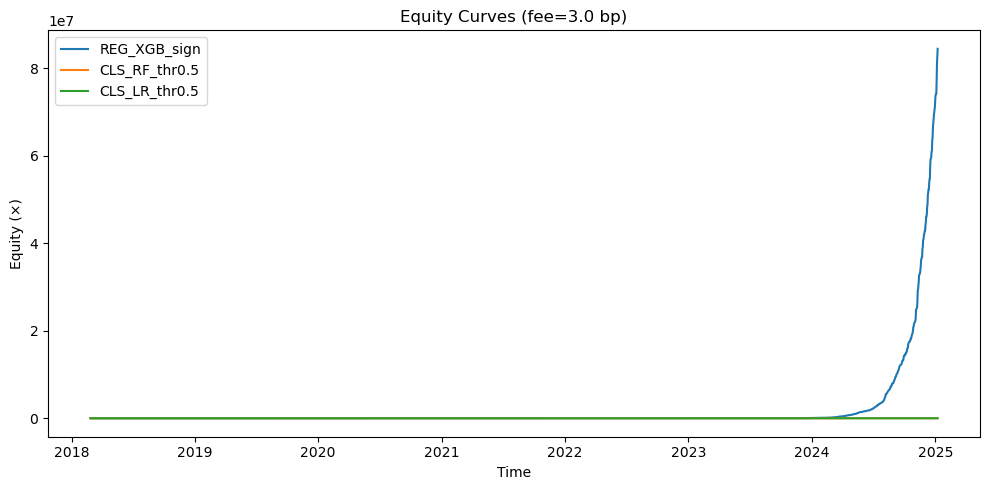

In [9]:
# ===== STEP 6 (adjusted): Multi-strategy trading backtest using all available predictions =====
# Compatible with Python 3.10+ (uses | for union types)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Backtest core
# -----------------------
def backtest_pnl(returns: pd.Series, signal: pd.Series, fee_bp: float = 3.0):
    """
    returns: actual next-period *raw* returns (Series aligned by index)
    signal : position in {-1, 0, +1} (aligned to returns)
    fee_bp : round-trip fee (basis points)
    """
    pos   = signal.fillna(0.0).astype(float)
    gross = pos * returns
    churn = pos.diff().abs().fillna(0.0)     # position flips/changes
    fee   = churn * (fee_bp / 10000.0)
    net   = gross - fee
    equity = (1.0 + net).cumprod()
    return equity, net

# -----------------------
# Helpers to coerce inputs to 1-D Series
# -----------------------
def _pick_proba_column(arr: np.ndarray, classes=None, pos_label=1):
    """
    arr: shape (n_samples, n_classes) or (n_samples,)
    classes: iterable of class labels aligned to columns in arr (e.g., estimator.classes_)
    pos_label: which class' probability to return (default assumes 'up' is 1)
    """
    if arr.ndim == 1:
        return arr
    if arr.shape[1] == 1:
        return arr.ravel()
    if classes is not None:
        classes = np.asarray(classes)
        if pos_label in classes:
            j = int(np.where(classes == pos_label)[0][0])
            return arr[:, j]
    # Fallback: take last column (common convention: prob of class 1)
    return arr[:, -1]

def _to_series(x, idx, name, *, is_proba: bool = False, classes=None, pos_label=1):
    """
    Coerce various inputs (Series, DataFrame, ndarray, list) to a 1-D pandas Series aligned to idx.
    If is_proba=True, selects the column corresponding to `pos_label` from (n, k) arrays/DataFrames.
    """
    if x is None:
        return None

    # Already a Series
    if isinstance(x, pd.Series):
        s = x.copy()
        return s.reindex(idx).rename(name)

    # DataFrame input
    if isinstance(x, pd.DataFrame):
        if is_proba:
            a = x.to_numpy()
            a = _pick_proba_column(a, classes=classes, pos_label=pos_label)
            s = pd.Series(a, index=idx, name=name)
        else:
            # If single column, use it; else take first column by default
            col = x.columns[0] if x.shape[1] >= 1 else None
            if col is None:
                return None
            s = x[col].copy()
            s.name = name
        return s.reindex(idx)

    # ndarray / list
    a = np.asarray(x)
    if is_proba:
        a = _pick_proba_column(a, classes=classes, pos_label=pos_label)
    elif a.ndim == 2 and a.shape[1] == 1:
        a = a.ravel()
    elif a.ndim > 1:
        a = np.squeeze(a)
        if a.ndim != 1:
            raise ValueError(f"{name}: cannot squeeze to 1-D; got shape {a.shape}")
    s = pd.Series(a, index=getattr(x, "index", idx), name=name)
    return s.reindex(idx)

# -----------------------
# Guards & alignment
# -----------------------
assert "dataset" in globals(), "dataset is missing."
assert "final_features" in globals(), "final_features is missing."
assert "target_col" in globals() or "target_reg" in globals(), "target variable name missing."

target_reg = globals().get("target_reg", None) or globals().get("target_col", None)
assert target_reg in dataset.columns, f"{target_reg} not found in dataset."

index = dataset.index

# Decide if target is log-return or simple-return (heuristic)
IS_LOG_TARGET = "log" in target_reg.lower()

true_target = dataset[target_reg].reindex(index).fillna(0.0)
true_ret = np.expm1(true_target) if IS_LOG_TARGET else true_target
true_ret = pd.Series(true_ret, index=index, name="true_ret")

# -----------------------
# Collect available prediction sources (from globals)
# -----------------------
# Optional: pass classifier classes arrays via globals if you have them
cls_rf_classes = globals().get("cls_classes", None)         # e.g., array([-1,0,1]) or array([0,1])
cls_lr_classes = globals().get("cls_classes_lr", None)

# Regression preds (e.g., RandomForestRegressor, XGBRegressor)
reg_rf   = _to_series(globals().get("reg_preds", None), index, "reg_rf")
reg_xgb  = _to_series(globals().get("xgb_preds", None), index, "reg_xgb")

# Classifier probabilities (ensure 1-D: probability of the "up" class)
proba_rf = _to_series(globals().get("cls_proba", None), index, "proba_rf",
                      is_proba=True, classes=cls_rf_classes, pos_label=1)
proba_lr = _to_series(globals().get("cls_proba_lr", None), index, "proba_lr",
                      is_proba=True, classes=cls_lr_classes, pos_label=1)

# Regression → raw returns if target was log-returns
def _pred_to_raw_ret(pred_series: pd.Series) -> pd.Series | None:
    if pred_series is None:
        return None
    if IS_LOG_TARGET:
        return pd.Series(np.expm1(pred_series.values), index=pred_series.index,
                         name=pred_series.name + "_raw")
    else:
        return pred_series.rename(pred_series.name + "_raw")

pred_rf_raw  = _pred_to_raw_ret(reg_rf)
pred_xgb_raw = _pred_to_raw_ret(reg_xgb)

# -----------------------
# Sanity checks
# -----------------------
for nm, s in {"reg_rf": reg_rf, "reg_xgb": reg_xgb, "proba_rf": proba_rf, "proba_lr": proba_lr}.items():
    if s is not None:
        assert s.ndim == 1, f"{nm} must be 1-D; got shape {getattr(s, 'shape', None)}"
        assert len(s) == len(index), f"{nm} length mismatch: {len(s)} vs {len(index)}"

# -----------------------
# Build strategy signals dict {-1,0,+1}
# -----------------------
strategies: dict[str, pd.Series] = {}

# 1) Sign(pred) from RF regression
if pred_rf_raw is not None:
    strategies["REG_RF_sign"] = np.sign(pred_rf_raw).rename("REG_RF_sign")

# 2) Sign(pred) from XGB regression
if pred_xgb_raw is not None:
    strategies["REG_XGB_sign"] = np.sign(pred_xgb_raw).rename("REG_XGB_sign")

# 3) Average of regressions → sign (if both available)
if (pred_rf_raw is not None) and (pred_xgb_raw is not None):
    avg_pred = ((pred_rf_raw.fillna(0) + pred_xgb_raw.fillna(0)) / 2.0)
    strategies["REG_AVG_sign"] = np.sign(avg_pred).rename("REG_AVG_sign")

# 4) Classifier RF probability → long/short by threshold
if proba_rf is not None:
    thr = 0.5
    sig = pd.Series(0.0, index=index)
    sig[proba_rf >= thr] = +1.0
    sig[proba_rf <  thr] = -1.0
    strategies["CLS_RF_thr0.5"] = sig.rename("CLS_RF_thr0.5")

# 5) Classifier LR probability → long/short by threshold
if proba_lr is not None:
    thr = 0.5
    sig = pd.Series(0.0, index=index)
    sig[proba_lr >= thr] = +1.0
    sig[proba_lr <  thr] = -1.0
    strategies["CLS_LR_thr0.5"] = sig.rename("CLS_LR_thr0.5")

# 6) Hybrid: average of regressions gated by classifier RF confidence (if available)
if ("REG_AVG_sign" in strategies) and (proba_rf is not None):
    # Gate to flat when classifier probability is too close to 0.5
    conf_band = 0.05  # inside (0.45,0.55) → go flat
    avg_sign = strategies["REG_AVG_sign"].copy()
    gate = (proba_rf - 0.5).abs() >= conf_band
    hybrid = avg_sign.where(gate, 0.0)
    strategies["HYBRID_avgReg_gateRF"] = hybrid.rename("HYBRID_avgReg_gateRF")

# 7) (Optional) If you have a 3-class classifier and want ternary argmax strategy
# Provide 'cls_proba' as (n,3) and 'cls_classes' like np.array([-1, 0, 1])
if globals().get("cls_proba", None) is not None and cls_rf_classes is not None:
    arr = np.asarray(globals()["cls_proba"])
    if arr.ndim == 2 and arr.shape[1] >= 3 and hasattr(cls_rf_classes, "__len__"):
        classes = np.asarray(cls_rf_classes)
        pred_class_idx = arr.argmax(axis=1)
        pred_class = classes[pred_class_idx]
        sig3 = pd.Series(0.0, index=index, dtype=float)
        # map predicted class to signal {-1,0,+1}
        sig3[pred_class == 1]  = +1.0
        sig3[pred_class == -1] = -1.0
        strategies["CLS_RF_3class_argmax"] = sig3.rename("CLS_RF_3class_argmax")

# --- If nothing is available, stop gracefully
if not strategies:
    raise RuntimeError("No predictions found (reg_preds/xgb_preds/cls_proba/cls_proba_lr). Run model steps first.")

# -----------------------
# Backtest each strategy
# -----------------------
fee_bp = 3.0
equity_curves: dict[str, pd.Series] = {}
summ_rows = []

for name, sig in strategies.items():
    # align & clean
    sig = sig.reindex(index).fillna(0.0).clip(-1.0, 1.0)
    eq, net = backtest_pnl(true_ret, sig, fee_bp=fee_bp)
    equity_curves[name] = eq

    # Summary stats
    tot_return = float(eq.iloc[-1] - 1.0)
    mean_net   = float(net.mean())
    vol_net    = float(net.std(ddof=1))
    sharpe     = (mean_net / vol_net * np.sqrt(252.0)) if vol_net > 0 else np.nan
    turnover   = float(sig.diff().abs().sum())
    hitrate    = float((np.sign(net) > 0).mean())

    summ_rows.append({
        "Strategy": name,
        "Bars": len(net),
        "Total Return (×-1)": tot_return,
        "Avg Net / bar": mean_net,
        "Std Net / bar": vol_net,
        "Sharpe≈": sharpe,
        "Turnover": turnover,
        "HitRate": hitrate,
    })

summary = pd.DataFrame(summ_rows).sort_values("Total Return (×-1)", ascending=False)
print(f"Fee: {fee_bp} bp round-trip | Target: {target_reg} | Interpreted as {'LOG' if IS_LOG_TARGET else 'SIMPLE'} returns")
print("\nStrategy summary:")
print(summary.to_string(index=False))

# -----------------------
# Plot all equity curves
# -----------------------
plt.figure(figsize=(10, 5))
for name, eq in equity_curves.items():
    plt.plot(eq.index, eq.values, label=name)
plt.title(f"Equity Curves (fee={fee_bp} bp)")
plt.xlabel("Time")
plt.ylabel("Equity (×)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


Top 15 permutation importances (test set):


,PI_mean,PI_std
momentum_pvo_hist,0.015701,0.007735
sma50,0.012846,0.004516
slope,0.012797,0.014941
open,0.009487,0.004924
high,0.008814,0.005789
momentum_pvo_signal,0.006784,0.002368
ema50,0.005944,0.004328
sent_neu,0.002706,0.005424
volume,0.001098,0.012788
momentum_pvo,0.000495,0.001545


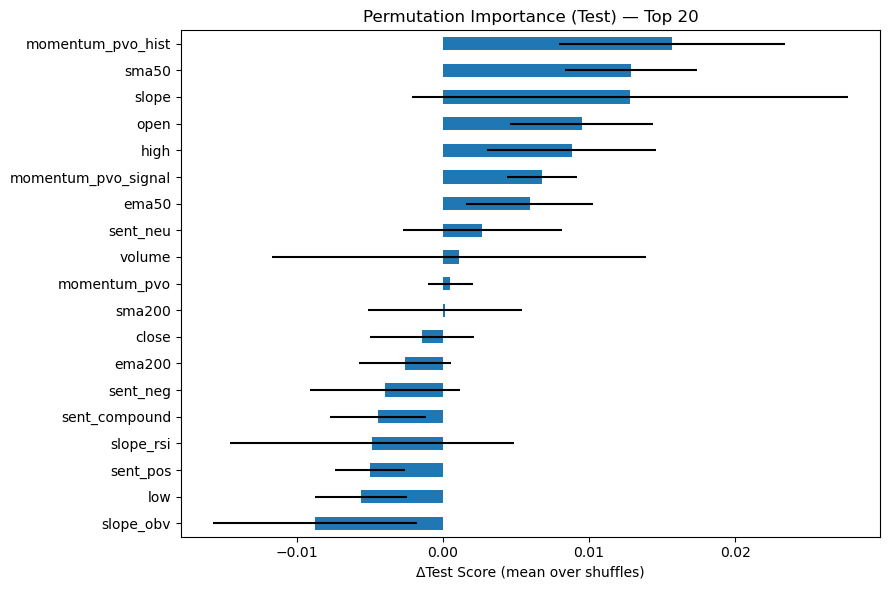


Bucketed permutation importance (sum of feature importances):


,PI_mean_sum
bucket,
technical,0.038561
market,0.012356
sentiment,-0.010668


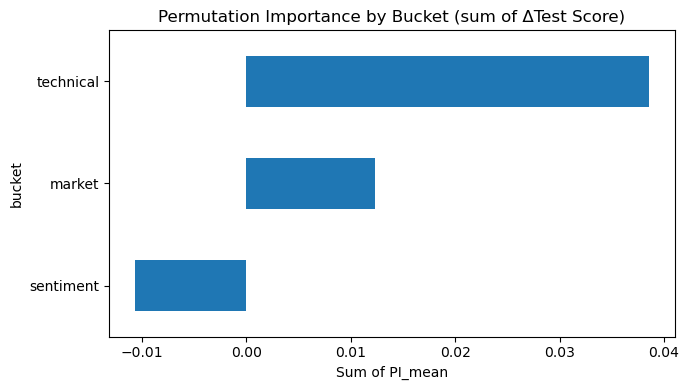


Top features within each bucket:


,bucket,top_features
0,technical,"momentum_pvo_hist (0.0157), sma50 (0.01285), s..."
1,market,"open (0.009487), high (0.008814), volume (0.00..."
2,sentiment,"sent_neu (0.002706), sent_neg (-0.003944), sen..."


In [10]:
# ===== STEP 7 (adjusted): Permutation importance including new features (network + sentiment) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# --- Guards
required_vars = ["X_train_scaled", "y_train", "X_test_scaled", "y_test", "final_features", "feature_catalog"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Missing variable `{v}`. Make sure the daily pipeline (split & scaling) ran successfully.")

if X_test_scaled.empty:
    raise RuntimeError("X_test_scaled is empty; cannot run permutation importance.")

# Align columns defensively (just in case something changed)
X_train_scaled = X_train_scaled[final_features]
X_test_scaled  = X_test_scaled[final_features]

# --- Fit a final model on the (train) split (no leakage: we never touch test until permutation)
rf_final = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_final.fit(X_train_scaled, y_train)

# --- Permutation importance ON TEST ONLY
imp = permutation_importance(
    rf_final, X_test_scaled, y_test,
    n_repeats=20, random_state=42, n_jobs=-1
)

perm_importance = pd.Series(imp.importances_mean, index=X_test_scaled.columns).sort_values(ascending=False)
perm_std        = pd.Series(imp.importances_std,  index=X_test_scaled.columns).reindex(perm_importance.index)

print("Top 15 permutation importances (test set):")
display(perm_importance.head(15).to_frame("PI_mean").assign(PI_std=perm_std.head(15)))

# --- Plot top-k individual features
top_k = 20
plt.figure(figsize=(9,6))
perm_importance.head(top_k).iloc[::-1].plot(kind="barh", xerr=perm_std.head(top_k).iloc[::-1].values)
plt.title("Permutation Importance (Test) — Top 20")
plt.xlabel("ΔTest Score (mean over shuffles)")
plt.tight_layout()
plt.show()

# ============ NEW: bucketed/grouped importance ============

# Map each feature to a bucket using your feature_catalog
bucket_of = {}
for bucket_name, cols in feature_catalog.items():
    for c in cols:
        bucket_of[c] = bucket_name

# Any feature not explicitly declared falls into 'other'
feature_buckets = [bucket_of.get(c, "other") for c in perm_importance.index]

imp_df = pd.DataFrame({
    "feature": perm_importance.index,
    "PI_mean": perm_importance.values,
    "PI_std":  perm_std.values,
    "bucket":  feature_buckets
})

# Aggregate by bucket (sum of importances; you can also try mean)
bucket_importance = (
    imp_df.groupby("bucket", dropna=False)["PI_mean"]
          .sum()
          .sort_values(ascending=False)
)

print("\nBucketed permutation importance (sum of feature importances):")
display(bucket_importance.to_frame("PI_mean_sum"))

# Plot bucketed view
plt.figure(figsize=(7,4))
bucket_importance.iloc[::-1].plot(kind="barh")
plt.title("Permutation Importance by Bucket (sum of ΔTest Score)")
plt.xlabel("Sum of PI_mean")
plt.tight_layout()
plt.show()

# ============ OPTIONAL: show top features per bucket ============
top_by_bucket_rows = []
for b in bucket_importance.index:
    top_feats = (
        imp_df[imp_df["bucket"] == b]
        .sort_values("PI_mean", ascending=False)
        .head(5)[["feature","PI_mean"]]
        .values
    )
    # store as a compact string
    top_by_bucket_rows.append({
        "bucket": b,
        "top_features": ", ".join([f"{f} ({v:.4g})" for f, v in top_feats])
    })

top_by_bucket = pd.DataFrame(top_by_bucket_rows)
print("\nTop features within each bucket:")
display(top_by_bucket)


In [11]:
# ===== STEP 8 (adjusted): Small hyperparameter search for RF (chronological, leakage-safe) =====
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# --- Guards
for v in ["dataset", "final_features", "target_col"]:
    if v not in globals():
        raise RuntimeError(f"Missing `{v}`. Run the daily pipeline first.")

features   = final_features
target_reg = target_col

# Outer split (80/20) — consistent with your pipeline
N = len(dataset)
split_idx = max(1, min(int(N * 0.8), N - 1))
train = dataset.iloc[:split_idx].copy()
test  = dataset.iloc[split_idx:].copy()

# Inner (chronological) validation split inside the train
inner_idx = max(1, min(int(len(train) * 0.8), len(train) - 1))
sub_tr = train.iloc[:inner_idx].copy()
sub_va = train.iloc[inner_idx:].copy()

X_tr, y_tr = sub_tr[features], sub_tr[target_reg]
X_va, y_va = sub_va[features], sub_va[target_reg]

# Scale inside inner split (no leakage)
sc_inner = StandardScaler().fit(X_tr)
X_trs = sc_inner.transform(X_tr)
X_vas = sc_inner.transform(X_va)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 2, 4],
}

best_score  = np.inf
best_params = None

for params in ParameterGrid(param_grid):
    rf = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    rf.fit(X_trs, y_tr)
    y_hat = rf.predict(X_vas)
    rmse = float(np.sqrt(mean_squared_error(y_va.values, y_hat)))
    if rmse < best_score:
        best_score, best_params = rmse, params
        print(f"New best on inner val — RMSE={best_score:.6f} | {best_params}")

print("\nBest RF params (inner val):", best_params)

# ---- Refit on FULL outer-train using best params, then evaluate on test ----
X_train_full, y_train_full = train[features], train[target_reg]
X_test_full,  y_test_full  = test[features],  test[target_reg]

sc_outer = StandardScaler().fit(X_train_full)
X_train_full_s = sc_outer.transform(X_train_full)
X_test_full_s  = sc_outer.transform(X_test_full)

rf_best = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
rf_best.fit(X_train_full_s, y_train_full)
y_test_pred = rf_best.predict(X_test_full_s)

rmse_test = float(np.sqrt(mean_squared_error(y_test_full.values, y_test_pred)))
mae_test  = float(np.mean(np.abs(y_test_full.values - y_test_pred)))
print(f"Outer Test — RMSE={rmse_test:.6f} | MAE={mae_test:.6f}")

# (Optional) keep predictions aligned for later analysis/backtests
rf_test_preds = pd.Series(y_test_pred, index=y_test_full.index, name="rf_test_pred")


New best on inner val — RMSE=0.027122 | {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
New best on inner val — RMSE=0.027008 | {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
New best on inner val — RMSE=0.026729 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
New best on inner val — RMSE=0.026674 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 400}
New best on inner val — RMSE=0.026370 | {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
New best on inner val — RMSE=0.026193 | {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 200}

Best RF params (inner val): {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 200}
Outer Test — RMSE=0.027140 | MAE=0.019362


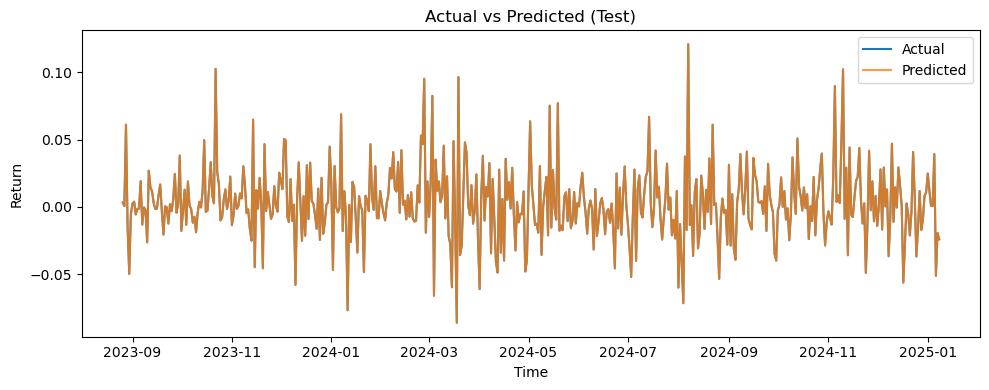

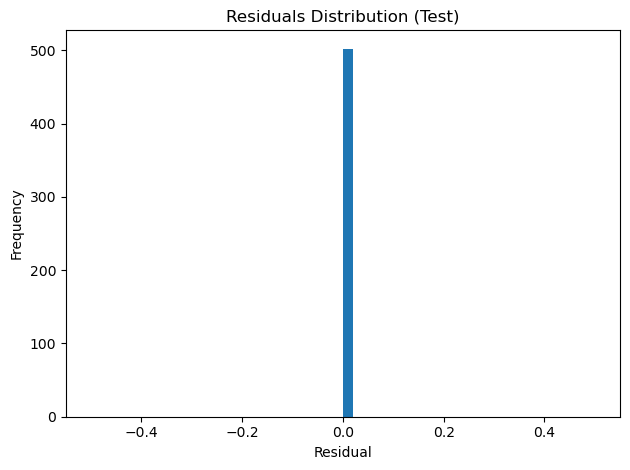

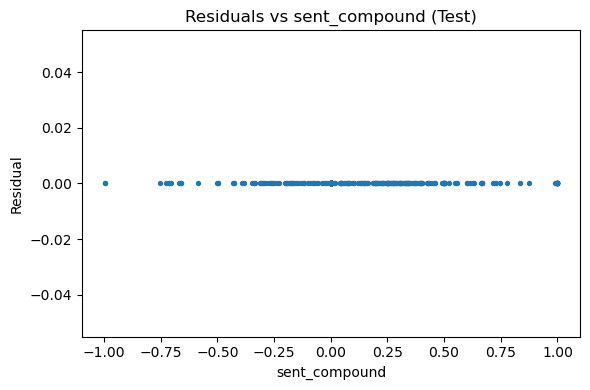

In [13]:
# ===== STEP 9 (adjusted): Sanity plots (no seaborn, single-plot rule) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Guards & setup
assert "dataset" in globals(), "Run the pipeline first: `dataset` is missing."
assert "final_features" in globals(), "final_features missing."

# y_test may be a Series (ideal) or an array; we’ll coerce it
assert "y_test" in globals(), "Run the train/test split first to define `y_test`."

# Use your regression target name
target_reg = globals().get("target_reg", None) or globals().get("target_col", None)
assert target_reg in dataset.columns, f"{target_reg} not found in dataset."

# Detect log vs simple returns from name
IS_LOG_TARGET = "log" in target_reg.lower()

# -----------------------
# Helpers
# -----------------------
def _coerce_series(x, idx=None, name="series"):
    """
    Make a 1-D pandas Series out of x (Series, DataFrame, ndarray, list).
    If DataFrame with multiple columns, take the first column by default.
    If ndarray is 2-D such as (n,1) or (n,k), squeeze; if still >1-D, raise.
    Align to idx if provided.
    """
    if x is None:
        return None

    if isinstance(x, pd.Series):
        s = x.copy()
    elif isinstance(x, pd.DataFrame):
        if x.shape[1] == 1:
            s = x.iloc[:, 0].copy()
        else:
            s = x.iloc[:, 0].copy()
        s.name = name
    else:
        a = np.asarray(x)
        if a.ndim > 1:
            a = np.squeeze(a)
            if a.ndim != 1:
                raise ValueError(f"{name}: cannot squeeze to 1-D; got shape {a.shape}")
        s = pd.Series(a, name=name)

    if idx is not None:
        # If s already has an index, try to reindex; else set index directly.
        if isinstance(s.index, pd.RangeIndex) and len(s) == len(idx):
            s.index = idx
        else:
            s = s.reindex(idx)
    return s

def _get_test_index():
    """
    Decide the test index to use for alignment:
    - Prefer y_test.index if y_test is a Series with an index
    - Else use X_test.index if present
    - Else fall back to prediction index (handled later)
    """
    if isinstance(y_test, pd.Series):
        return y_test.index
    if "X_test" in globals() and isinstance(X_test, (pd.DataFrame, pd.Series)):
        return X_test.index
    return None

# -----------------------
# Build y_true (visual space toggle handled below)
# -----------------------
test_index = _get_test_index()

y_true_raw = _coerce_series(y_test, idx=test_index, name="y_true_raw")
if y_true_raw is None:
    raise RuntimeError("Could not coerce y_test into a Series.")

# -----------------------
# Pick a prediction source (try RF, then XGB) and coerce
# -----------------------
pred_series = None
if "reg_preds" in globals() and globals()["reg_preds"] is not None:
    pred_series = _coerce_series(globals()["reg_preds"], idx=test_index, name="y_pred")
elif "xgb_preds" in globals() and globals()["xgb_preds"] is not None:
    pred_series = _coerce_series(globals()["xgb_preds"], idx=test_index, name="y_pred")
else:
    raise RuntimeError("No regression predictions found (reg_preds/xgb_preds).")

# If we still lack an index (both y_test and X_test had no index), adopt prediction’s index
if test_index is None:
    test_index = pred_series.index
    y_true_raw = _coerce_series(y_test, idx=test_index, name="y_true_raw")

# Final align (and drop rows where either is missing)
aligned = pd.concat([y_true_raw, pred_series], axis=1, join="inner").dropna()
y_true_raw = aligned.iloc[:, 0]
y_pred_raw = aligned.iloc[:, 1]

# If target is log-return but you want to visualize in simple-return space, toggle below:
VISUALIZE_AS_SIMPLE = False  # set True to show simple returns even when target is log

if IS_LOG_TARGET and VISUALIZE_AS_SIMPLE:
    y_true_vis = pd.Series(np.expm1(y_true_raw.values), index=y_true_raw.index, name="y_true")
    y_pred_vis = pd.Series(np.expm1(y_pred_raw.values), index=y_pred_raw.index, name="y_pred")
    y_label = "Return"
else:
    y_true_vis = y_true_raw.rename("y_true")
    y_pred_vis = y_pred_raw.rename("y_pred")
    y_label = "Log-Return" if IS_LOG_TARGET else "Return"

# -----------------------
# 1) Actual vs Predicted on the test period
# -----------------------
plt.figure(figsize=(10, 4))
plt.plot(y_true_vis.index, y_true_vis.values, label="Actual")
plt.plot(y_pred_vis.index, y_pred_vis.values, label="Predicted", alpha=0.8)
plt.legend()
plt.title("Actual vs Predicted (Test)")
plt.xlabel("Time")
plt.ylabel(y_label)
plt.tight_layout()
plt.show()

# -----------------------
# 2) Residuals histogram (test)
# -----------------------
resid = (y_true_vis - y_pred_vis).values
plt.figure()
plt.hist(resid, bins=50)
plt.title("Residuals Distribution (Test)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------
# 3) Residuals vs Network feature (hash_rate)
#     (robust to large scale via log1p if needed)
# -----------------------
def _safe_col_name(candidates):
    for c in candidates:
        if c in dataset.columns:
            return c
    return None

hash_col = _safe_col_name(["hash_rate", "hashrate", "hash_rate_smooth", "hash_rate_log"])
if hash_col is not None:
    hr_test = dataset.loc[y_true_vis.index, hash_col].astype(float)
    # decide if we need log1p scale
    hr_min = float(hr_test.min()) if np.isfinite(hr_test.min()) else 0.0
    hr_max = float(hr_test.max()) if np.isfinite(hr_test.max()) else 0.0
    large_scale = (hr_max > 0) and ((hr_max / max(abs(hr_min), 1e-9)) > 1e4)

    hr_plot = np.log1p(hr_test) if large_scale and ("log" not in hash_col) else hr_test
    xy = pd.DataFrame({"x": hr_plot.values, "y": (y_true_vis - y_pred_vis).values}).dropna()

    plt.figure(figsize=(6, 4))
    plt.scatter(xy["x"], xy["y"], s=8)
    tnote = " (log1p)" if (large_scale and ("log" not in hash_col)) else ""
    plt.title(f"Residuals vs {hash_col}{tnote} (Test)")
    plt.xlabel(f"{hash_col}{tnote}")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

# -----------------------
# 4) Residuals vs Sentiment feature (sent_compound)
# -----------------------
sent_col = _safe_col_name(["sent_compound", "sentiment_compound", "sent_mean"])
if sent_col is not None:
    sc_test = dataset.loc[y_true_vis.index, sent_col].astype(float)
    xy = pd.DataFrame({"x": sc_test.values, "y": (y_true_vis - y_pred_vis).values}).dropna()

    plt.figure(figsize=(6, 4))
    plt.scatter(xy["x"], xy["y"], s=8)
    plt.title(f"Residuals vs {sent_col} (Test)")
    plt.xlabel(f"{sent_col}")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()


[LSTM] Cadence detected: DAILY | Window=30 | Epochs=25
Seq shapes (train/test): (2003, 30, 19) (476, 30, 19)
Epoch 1/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.0875 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 2/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0260 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 3/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0162 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 4/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0180 - val_loss: 0.0242 - learning_rate: 5.0000e-04
Epoch 5/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0183 - val_loss: 0.0143 - learning_rate: 5.0000e-04
Epoch 6/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0136 - val_loss: 0.0081 - learning_rate: 5.0000e-04
Epoch 7/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0111 - val_loss: 0.0061 - learning_rate: 5.0000e-04
Epoch 8/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0097 - val_loss: 0.0051 - learning_rate: 5.0000e-04

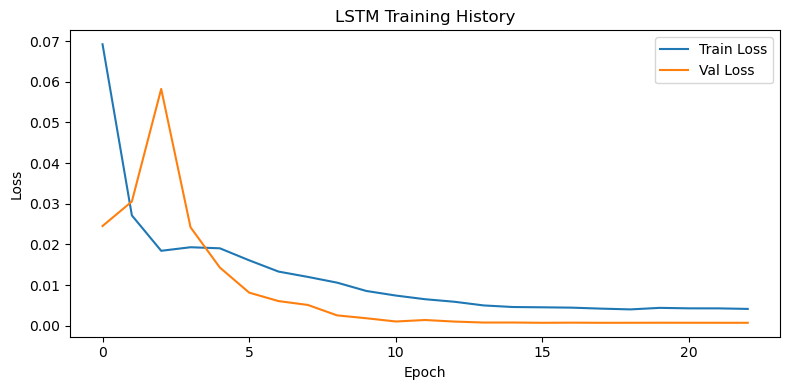

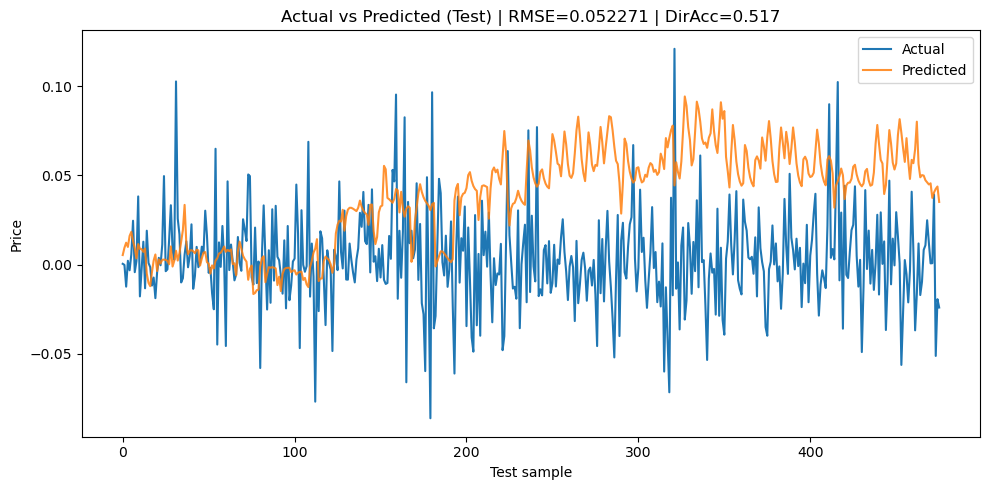

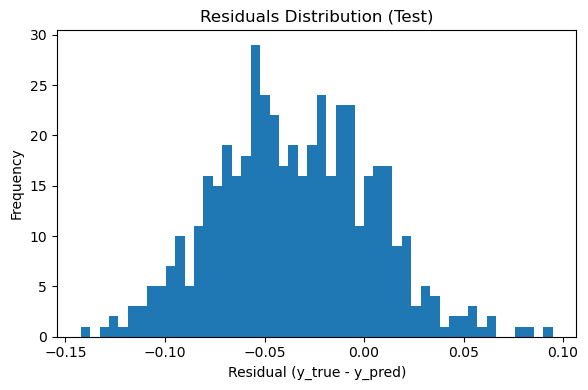

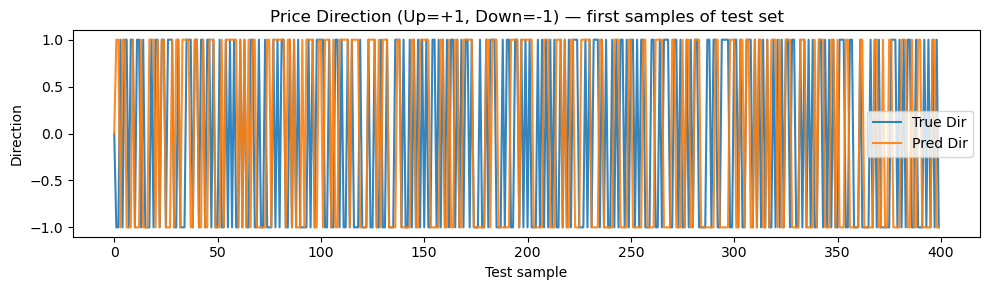

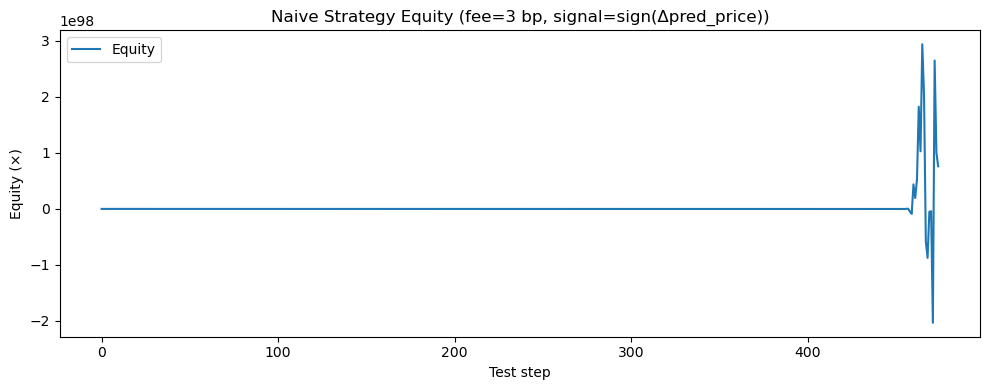

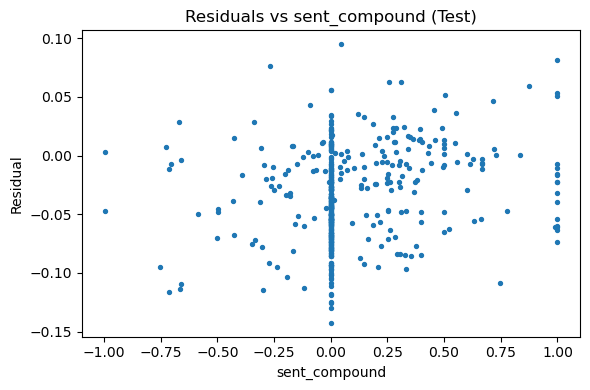

In [18]:
# =========================
# LSTM: robust train + outputs + analysis plots + (optional) equity backtest
# =========================
# Python ≥3.10
import os, gc, time, math, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# ------- Guards / Inputs -------
assert "dataset" in globals(), "`dataset` DataFrame missing."
assert "final_features" in globals(), "`final_features` missing."
assert isinstance(final_features, (list, tuple)) and len(final_features) > 0, "final_features must be non-empty."
assert all(f in dataset.columns for f in final_features), "Some `final_features` are not in dataset columns."

target_name = globals().get("target_reg", None) or globals().get("target_col", None)
assert target_name in dataset.columns, f"{target_name} not in dataset."

# Heuristic to tag target space (only used for the footer label)
IS_LOG_TARGET = "log" in str(target_name).lower()

# ------- TensorFlow / Keras -------
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.get_logger().setLevel("ERROR")
except Exception as e:
    raise RuntimeError("TensorFlow/Keras required for this step.") from e

# ------- Determinism & device options -------
def set_global_determinism(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        tf.random.set_seed(seed)
    except Exception:
        pass
    try:
        tf.config.threading.set_intra_op_parallelism_threads(1)
        tf.config.threading.set_inter_op_parallelism_threads(1)
    except Exception:
        pass
    try:
        gpus = tf.config.list_physical_devices("GPU")
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

set_global_determinism(42)

# ------- Cadence detector (log header) -------
def detect_cadence(idx: pd.DatetimeIndex) -> str:
    if not isinstance(idx, pd.DatetimeIndex) or len(idx) < 2:
        return "UNKNOWN"
    step = (idx[1] - idx[0]).total_seconds()
    return "HOURLY" if step <= 3600 + 1 else "DAILY"

# ------- Sequence builder (price or return targets both OK) -------
def build_lstm_sequences(df: pd.DataFrame, feat_cols, target_col, window=30, test_size=0.192):
    df = df.sort_index()
    X_mat = df[feat_cols].astype(float).values
    y_vec = df[target_col].astype(float).values

    X_seq, y_seq = [], []
    for i in range(window, len(df)):
        X_seq.append(X_mat[i-window:i, :])
        y_seq.append(y_vec[i])

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=np.float32)

    n = len(X_seq)
    n_test = max(1, int(math.ceil(n * test_size)))
    n_train = n - n_test

    X_train, X_test = X_seq[:n_train], X_seq[n_train:]
    y_train, y_test = y_seq[:n_train], y_seq[n_train:]

    return X_train, X_test, y_train, y_test, X_seq.shape[-1]

# ------- Model factory -------
def make_lstm_model(n_features: int, units: int = 64, lr: float = 1e-3, dropout: float = 0.2):
    keras.backend.clear_session()
    inputs = keras.Input(shape=(None, n_features))
    x = layers.LSTM(units, return_sequences=True)(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(units)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

# ------- Time limit callback (prevents stalls) -------
class TimeLimitCallback(keras.callbacks.Callback):
    def __init__(self, max_seconds: float | None = None):
        super().__init__()
        self.max_seconds = max_seconds
        self._start = None
    def on_train_begin(self, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        if self.max_seconds is not None and (time.time() - self._start) > self.max_seconds:
            self.model.stop_training = True

# ------- Training with retries -------
def train_lstm_with_retries(
    df: pd.DataFrame,
    feat_cols,
    target_col,
    window: int = 30,
    epochs: int = 25,
    batch_size: int = 64,
    test_size: float = 0.192,
    lr: float = 1e-3,
    dropout: float = 0.2,
    units: int = 64,
    max_seconds: float | None = None,
    max_retries: int = 2,
):
    cadence = detect_cadence(df.index)
    print(f"[LSTM] Cadence detected: {cadence} | Window={window} | Epochs={epochs}")

    X_train, X_test, y_train, y_test, n_features = build_lstm_sequences(
        df, feat_cols, target_col, window=window, test_size=test_size
    )
    print(f"Seq shapes (train/test): {X_train.shape} {X_test.shape}")

    early = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=0
    )
    csv_log = keras.callbacks.CSVLogger("lstm_training_log.csv", append=False)
    nan_term = keras.callbacks.TerminateOnNaN()
    time_limit = TimeLimitCallback(max_seconds=max_seconds)

    history = None
    y_pred_test = None
    model = None
    attempt = 0

    while attempt <= max_retries:
        try:
            model = make_lstm_model(n_features=n_features, units=units, lr=lr, dropout=dropout)
            history = model.fit(
                X_train, y_train,
                validation_split=0.1,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=False,
                verbose=1,
                callbacks=[early, reduce_lr, csv_log, nan_term, time_limit]
            )
            y_pred_test = model.predict(X_test, batch_size=batch_size, verbose=0).reshape(-1)
            break
        except tf.errors.ResourceExhaustedError:
            attempt += 1
            batch_size = max(8, batch_size // 2)
            units = max(16, units // 2)
            print(f"[Retry {attempt}] OOM → reducing batch_size={batch_size}, units={units} and retrying...")
            gc.collect(); time.sleep(0.5)
        except Exception as ex:
            attempt += 1
            print(f"[Retry {attempt}] Exception during training: {type(ex).__name__}: {ex}")
            batch_size = max(8, batch_size // 2)
            gc.collect(); time.sleep(0.5)

    if y_pred_test is None:
        raise RuntimeError("Training failed after retries.")

    rmse = float(np.sqrt(np.mean((y_pred_test - y_test) ** 2)))
    dir_acc = float((np.sign(np.diff(np.r_[y_test[0], y_test])) == np.sign(np.diff(np.r_[y_pred_test[0], y_pred_test]))).mean())

    return {
        "model": model,
        "history": history,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "y_pred_test": y_pred_test,
        "rmse": rmse,
        "dir_acc": dir_acc,
        "cadence": cadence,
        "window": window,
        "epochs": len(history.history["loss"]) if history is not None else 0,
    }

# ------- Equity backtest (optional) from price predictions -------
def backtest_from_price_predictions(y_true: np.ndarray, y_pred: np.ndarray, fee_bp: float = 3.0):
    """
    Build a naive long/short signal from predicted price direction:
    signal_t = sign(pred_{t} - pred_{t-1}), applied to next-period return on y_true.
    """
    # compute actual next-step returns from true price
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)

    true_ret = np.diff(y_true) / y_true[:-1]  # simple return
    pred_dir = np.sign(np.diff(y_pred))      # -1/0/+1

    # align lengths
    n = min(len(true_ret), len(pred_dir))
    true_ret = true_ret[:n]
    pred_dir = pred_dir[:n]

    # fees on position changes
    pos = pred_dir
    churn = np.abs(np.diff(np.r_[0.0, pos]))  # position changes
    fee = churn * (fee_bp / 10000.0)

    net = pos * true_ret - fee
    equity = (1.0 + net).cumprod()
    return pd.Series(equity, name="Equity"), pd.Series(net, name="NetRet")

# =========================
# RUN
# =========================
# 1) Prepare working frame
work_df = dataset[[*final_features, target_name]].dropna().copy()
cadence = detect_cadence(work_df.index)

# 2) Train
MAX_TRAIN_SECONDS = None  # e.g., 300 to hard-cap wall time
res = train_lstm_with_retries(
    df=work_df,
    feat_cols=final_features,
    target_col=target_name,
    window=30,
    epochs=25,
    batch_size=64,
    test_size=0.192,  # ~80/20
    lr=1e-3,
    dropout=0.2,
    units=64,
    max_seconds=MAX_TRAIN_SECONDS,
    max_retries=2,
)

model = res["model"]
history = res["history"]
y_test = res["y_test"]
y_pred = res["y_pred_test"]
rmse = res["rmse"]
dir_acc = res["dir_acc"]

# 3) Footer (your requested style)
print(f"LSTM ({'price' if not IS_LOG_TARGET else 'log'}) Test RMSE: {rmse}")
print(f"LSTM ({'price' if not IS_LOG_TARGET else 'log'}) Directional Acc: {dir_acc}")

# =========================
# VISUALIZATION (no seaborn, one plot per figure)
# =========================

# A) Training history
if history is not None:
    plt.figure(figsize=(8,4))
    plt.plot(history.history.get('loss', []), label='Train Loss')
    plt.plot(history.history.get('val_loss', []), label='Val Loss')
    plt.title("LSTM Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# B) Actual vs Predicted (Test)
y_true_series = pd.Series(y_test.reshape(-1), name="Actual")
y_pred_series = pd.Series(y_pred.reshape(-1), name="Predicted")

plt.figure(figsize=(10,5))
plt.plot(y_true_series.index, y_true_series.values, label="Actual")
plt.plot(y_pred_series.index, y_pred_series.values, label="Predicted", alpha=0.85)
plt.title(f"Actual vs Predicted (Test) | RMSE={rmse:.6f} | DirAcc={dir_acc:.3f}")
plt.xlabel("Test sample")
plt.ylabel("Price" if not IS_LOG_TARGET else "Log-space target")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# C) Residuals histogram
residuals = y_true_series.values - y_pred_series.values
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title("Residuals Distribution (Test)")
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# D) Directional signals (first N samples for readability)
true_dir = np.sign(np.diff(np.r_[y_true_series.values[0], y_true_series.values]))
pred_dir = np.sign(np.diff(np.r_[y_pred_series.values[0], y_pred_series.values]))

N = min(400, len(true_dir))
plt.figure(figsize=(10,3))
plt.plot(range(N), true_dir[:N], label="True Dir", alpha=0.9)
plt.plot(range(N), pred_dir[:N], label="Pred Dir", alpha=0.9)
plt.title("Price Direction (Up=+1, Down=-1) — first samples of test set")
plt.xlabel("Test sample")
plt.ylabel("Direction")
plt.legend()
plt.tight_layout()
plt.show()

# E) (Optional) Equity backtest from predicted direction on prices
DO_EQUITY_BACKTEST = True
if DO_EQUITY_BACKTEST and len(y_true_series) > 2:
    equity, net = backtest_from_price_predictions(y_true_series.values, y_pred_series.values, fee_bp=3.0)
    plt.figure(figsize=(10,4))
    plt.plot(equity.index, equity.values, label="Equity")
    plt.title("Naive Strategy Equity (fee=3 bp, signal=sign(Δpred_price))")
    plt.xlabel("Test step")
    plt.ylabel("Equity (×)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# (Optional) Residuals vs Features for diagnostics
# =========================
def _safe_get(colnames):
    for c in colnames:
        if c in work_df.columns:
            return c
    return None

hash_col = _safe_get(["hash_rate", "hashrate", "hash_rate_smooth", "hash_rate_log"])
if hash_col is not None:
    # Align last len(y_true_series) rows to test period used above
    test_idx = work_df.index[-len(y_true_series):]
    hr = pd.Series(work_df.loc[test_idx, hash_col].astype(float).values, index=range(len(y_true_series)))
    # if huge scale, log1p (and label)
    hr_vals = hr.values
    scale_note = ""
    if np.nanmax(np.abs(hr_vals)) > 0 and (np.nanmax(hr_vals) / max(np.nanmin(np.abs(hr_vals)), 1e-9) > 1e4):
        hr_vals = np.log1p(np.clip(hr_vals, a_min=0, a_max=None))
        scale_note = " (log1p)"
    plt.figure(figsize=(6,4))
    plt.scatter(hr_vals, residuals, s=8)
    plt.title(f"Residuals vs {hash_col}{scale_note} (Test)")
    plt.xlabel(f"{hash_col}{scale_note}")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

sent_col = _safe_get(["sent_compound", "sentiment_compound", "sent_mean"])
if sent_col is not None:
    test_idx = work_df.index[-len(y_true_series):]
    sc = pd.Series(work_df.loc[test_idx, sent_col].astype(float).values, index=range(len(y_true_series)))
    plt.figure(figsize=(6,4))
    plt.scatter(sc.values, residuals, s=8)
    plt.title(f"Residuals vs {sent_col} (Test)")
    plt.xlabel(sent_col)
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()


[LSTM-LOGRET] Cadence: DAILY | Window=30 | Epochs=25
Seq shapes (train/test): (1976, 30, 19) (472, 30, 19)
Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - loss: 0.0391 - val_loss: 0.0033
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0143 - val_loss: 0.0017
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0078 - val_loss: 0.0017
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.0057 - val_loss: 0.0013
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.0042 - val_loss: 8.6281e-04
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.0041 - val_loss: 0.0010
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0032 - val_loss: 8.9368e-04
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 0.0031 - val_loss: 8.3234e-04
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - loss: 0.0030 - val_loss: 9.7478e-04
Epoch 10/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0028 - val_loss: 7.4353e-04
Epoch 11/25
7/7 ━━━━━━━━━━━━━━━━

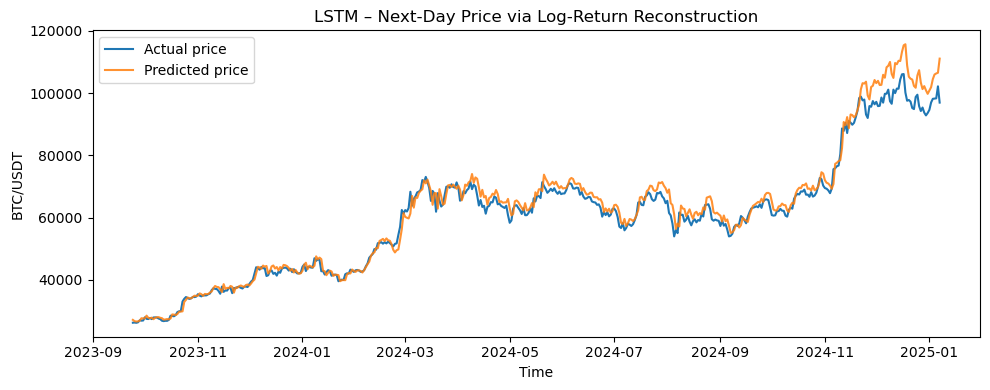

In [19]:
# ===== STEP 10b: LSTM — Next-period PRICE via LOG-RETURN (reconstruction), using all features =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler

# ---------- Guards ----------
assert "dataset" in globals() and "final_features" in globals(), "Run the pipeline first."
assert isinstance(dataset.index, pd.DatetimeIndex), "dataset index must be a DateTimeIndex."

# ---------- Cadence detection (daily vs hourly) ----------
_median_step = dataset.index.to_series().diff().median()
is_daily = (_median_step is not pd.NaT) and (_median_step >= pd.Timedelta(hours=23))
WINDOW = 30 if is_daily else 24   # ~1 month if daily, 1 day if hourly
VAL_SPLIT = 0.1
EPOCHS    = 25
BATCH     = 256

print(f"[LSTM-LOGRET] Cadence: {'DAILY' if is_daily else 'HOURLY'} | Window={WINDOW} | Epochs={EPOCHS}")

# ---------- Build log-return target ----------
df_lr = dataset.copy()
df_lr["log_price"]   = np.log(df_lr["close"])
df_lr["y_logret_t1"] = df_lr["log_price"].shift(-1) - df_lr["log_price"]  # log(P_{t+1}) - log(P_t)
df_lr["P_t"]         = df_lr["close"]                                      # to reconstruct P_{t+1} = P_t * exp(y_logret_t1)

# Keep rows where target & P_t are available
df_lr = df_lr.dropna(subset=["y_logret_t1", "P_t"]).copy()

# ---------- Feature set (includes market/technical/network/sentiment) ----------
use_features = [f for f in final_features if f in df_lr.columns]
if not use_features:
    raise RuntimeError("No usable features for LSTM. Check `final_features` vs dataset columns.")

# Forward-fill features only (no bfill to avoid peeking)
df_lr[use_features] = df_lr[use_features].ffill()

# ---------- Chronological split (80/20) ----------
split_idx = int(len(df_lr) * 0.8)
train = df_lr.iloc[:split_idx].copy()
test  = df_lr.iloc[split_idx:].copy()

# ---------- Scale features on TRAIN only (no leakage) ----------
X_scaler = StandardScaler().fit(train[use_features])
Xtr = pd.DataFrame(X_scaler.transform(train[use_features]), index=train.index, columns=use_features)
Xte = pd.DataFrame(X_scaler.transform(test[use_features]),  index=test.index,  columns=use_features)

# Targets (log-returns are already ~zero-mean small scale → no target scaler needed)
ytr = train["y_logret_t1"].astype(np.float32)
yte = test["y_logret_t1"].astype(np.float32)

# P_t for reconstruction aligned to test indices
Pt_test = test["P_t"].astype(np.float32)

# ---------- Sequence builder ----------
def make_sequences(X_df, y_series, window: int):
    Xv = X_df.values.astype(np.float32)
    yv = y_series.values.astype(np.float32)
    X_seq, y_seq, idx = [], [], []
    for i in range(window, len(Xv)):
        X_seq.append(Xv[i-window:i])
        y_seq.append(yv[i])
        idx.append(X_df.index[i])
    return np.array(X_seq), np.array(y_seq), pd.Index(idx)

Xtr_seq, ytr_seq, _     = make_sequences(Xtr, ytr, window=WINDOW)
Xte_seq, yte_seq, idx_t = make_sequences(Xte, yte, window=WINDOW)

if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
    raise RuntimeError("Not enough rows to build sequences. Reduce WINDOW or provide more data.")

# Align P_t to test sequence timestamps
Pt_seq = Pt_test.loc[idx_t].values

print("Seq shapes (train/test):", Xtr_seq.shape, Xte_seq.shape)

# ---------- Model ----------
model = models.Sequential([
    layers.Input(shape=(Xtr_seq.shape[1], Xtr_seq.shape[2])),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

hist = model.fit(
    Xtr_seq, ytr_seq,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1,
    callbacks=[early_stop]
)

# ---------- Predict log-returns → reconstruct price ----------
yhat_logret = model.predict(Xte_seq, verbose=0).ravel().astype(np.float64)
ytrue_logret = yte_seq.astype(np.float64)

# P_{t+1} = P_t * exp(logret_{t→t+1})
yhat_price  = Pt_seq * np.exp(yhat_logret)
ytrue_price = Pt_seq * np.exp(ytrue_logret)

# ---------- Metrics ----------
def rmse_np(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def directional_accuracy_price(y_true, y_pred):
    true_dir = np.sign(np.diff(y_true, prepend=y_true[0]))
    pred_dir = np.sign(np.diff(y_pred, prepend=y_pred[0]))
    return float((true_dir == pred_dir).mean())

print("LSTM (log-return→price) Test RMSE:", rmse_np(ytrue_price, yhat_price))
print("LSTM (log-return→price) Directional Acc:", directional_accuracy_price(ytrue_price, yhat_price))

# ---------- Plot ----------
plt.figure(figsize=(10,4))
plt.plot(idx_t, ytrue_price, label="Actual price")
plt.plot(idx_t, yhat_price,  label="Predicted price", alpha=0.85)
title_freq = "Next-Day" if is_daily else "Next-Hour"
plt.title(f"LSTM – {title_freq} Price via Log-Return Reconstruction")
plt.xlabel("Time"); plt.ylabel("BTC/USDT")
plt.legend(); plt.tight_layout()
plt.show()

# (Optional) keep predictions for later backtests
lstm_logret_preds = pd.Series(yhat_logret, index=idx_t, name="lstm_pred_logret_t1")
lstm_price_preds  = pd.Series(yhat_price,  index=idx_t, name="lstm_pred_price_t1")


In [20]:
# ===== DATA QUALITY DIAGNOSTICS (cadence-aware; includes new features) =====
import pandas as pd
import numpy as np

# Pick a frame to inspect: prefer your modeling frame if present
df_to_check = None
if "df_daily" in globals():
    df_to_check = df_daily.copy()
elif "dataset" in globals():
    # dataset is post-shift; for quality checks on raw features use the unshifted df if you kept one.
    df_to_check = dataset.copy()
elif "df" in globals():
    df_to_check = df.copy()
else:
    raise RuntimeError("No dataframe found. Expected one of: df_daily, dataset, or df.")

if not isinstance(df_to_check.index, pd.DatetimeIndex):
    raise TypeError("DataFrame index must be a DatetimeIndex.")

# --- Cadence detection ---
med_step = df_to_check.index.to_series().diff().median()
is_daily = (med_step is not pd.NaT) and (med_step >= pd.Timedelta(hours=23))
freq_label = "DAILY" if is_daily else "HOURLY"

print(f"[INFO] Cadence detected: {freq_label}")
print("Index range:", df_to_check.index.min(), "→", df_to_check.index.max())
print("Rows:", len(df_to_check), "| Cols:", len(df_to_check.columns))

# --- Duplicates (exact timestamp duplicates) ---
dup_count = df_to_check.index.duplicated(keep="first").sum()
print("Duplicate timestamps:", int(dup_count))

# --- Gaps against expected cadence ---
freq = "D" if is_daily else "H"
expected = pd.date_range(df_to_check.index.min(), df_to_check.index.max(), freq=freq)
missing = expected.difference(df_to_check.index)
print(f"Missing {freq_label.lower()} bars:", len(missing))

# --- OHLCV existence check ---
ohlcv_cols = ["open","high","low","close","volume"]
missing_ohlcv = [c for c in ohlcv_cols if c not in df_to_check.columns]
if missing_ohlcv:
    print("[WARN] Missing OHLCV columns:", missing_ohlcv)
else:
    # sanity: first/max/min/last relations on any one day (for hourly), or globally (for daily)
    if not is_daily:
        day = df_to_check.index.normalize().unique()[0]
        day_slice = df_to_check[df_to_check.index.normalize() == day][ohlcv_cols]
        if not day_slice.empty:
            ok_open  = np.isfinite(day_slice["open"].iloc[0])
            ok_close = np.isfinite(day_slice["close"].iloc[-1])
            print(f"OHLCV sanity (first open finite? {ok_open}) (last close finite? {ok_close})")
    else:
        ok_any = df_to_check[ohlcv_cols].dropna().shape[0] > 0
        print(f"OHLCV sanity (has non-NaN rows?): {ok_any}")

# --- Feature catalog (use yours if available; otherwise define a minimal one) ---
if "feature_catalog" not in globals():
    feature_catalog = {
        "market": ohlcv_cols,
        "technical": [
            "sma200","sma50","ema200","ema50","RSI","rsi","slope_rsi","MACD","macd",
            "OBV","obv","Bollinger_Upper","Bollinger_Lower",
            "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
            "slope","slope_obv",
        ],
        "network": ["hash_rate","mining_difficulty"],
        "sentiment": ["sent_pos","sent_neu","sent_neg","sent_compound"],
    }

# --- Coverage by feature & by bucket (non-NaN ratio) ---
all_feats = sorted(set(sum(feature_catalog.values(), [])))
present = [c for c in all_feats if c in df_to_check.columns]
missing_feats = [c for c in all_feats if c not in df_to_check.columns]
if missing_feats:
    print("\n[INFO] Declared but missing features:", missing_feats)

cov = df_to_check[present].notna().mean().sort_values(ascending=False)
cov_df = cov.to_frame("non_na_ratio")
cov_df["bucket"] = [next((b for b, cols in feature_catalog.items() if f in cols), "other") for f in cov_df.index]

print("\nTop 15 features by coverage:")
print(cov_df.head(15))

bucket_cov = cov_df.groupby("bucket")["non_na_ratio"].mean().sort_values(ascending=False)
print("\nAverage coverage by bucket:")
print(bucket_cov)

# --- Explicit checks for new features (network + sentiment) ---
for col in ["hash_rate","mining_difficulty","sent_pos","sent_neu","sent_neg","sent_compound"]:
    if col in df_to_check.columns:
        non_na = float(df_to_check[col].notna().mean())
        start  = df_to_check.index[df_to_check[col].notna()].min()
        end    = df_to_check.index[df_to_check[col].notna()].max()
        print(f"{col:>16} | coverage={non_na:6.2%} | range: {start} → {end}")
    else:
        print(f"{col:>16} | (missing)")

# --- Top NaN columns (all columns, not only declared) ---
nan_counts = df_to_check.isna().sum().sort_values(ascending=False)
print("\nTop NaN columns (absolute counts):")
print(nan_counts.head(10))

# --- Hourly→daily join quality hint (only if daily and you expect forward-filled day-level joins) ---
if is_daily:
    # days with any sentiment info
    if all(c in df_to_check.columns for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]):
        days_with_sent = df_to_check[["sent_pos","sent_neu","sent_neg","sent_compound"]].notna().any(axis=1).sum()
        print(f"\n[DAILY] Days with any sentiment data: {days_with_sent} / {len(df_to_check)}")
    if "hash_rate" in df_to_check.columns:
        days_with_hr = df_to_check["hash_rate"].notna().sum()
        print(f"[DAILY] Days with hash_rate: {days_with_hr} / {len(df_to_check)}")
else:
    # If this is hourly, check within-day constancy for day-level features (they should be constant after merge/ffill)
    day_groups = df_to_check.index.normalize()
    for col in ["hash_rate","mining_difficulty","sent_compound"]:
        if col in df_to_check.columns:
            within_day_var = df_to_check.groupby(day_groups)[col].nunique(dropna=True).mean()
            print(f"[HOURLY] mean unique values per day for {col}: {within_day_var:.2f} (expect ~1.0 if daily→hourly merge OK)")


[INFO] Cadence detected: DAILY
Index range: 2017-08-17 00:00:00 → 2025-01-09 00:00:00
Rows: 2703 | Cols: 110
Duplicate timestamps: 0
Missing daily bars: 0
OHLCV sanity (has non-NaN rows?): True

[INFO] Declared but missing features: ['Bollinger_Lower', 'Bollinger_Upper', 'MACD', 'OBV', 'RSI', 'macd', 'mining_difficulty', 'obv', 'rsi']

Top 15 features by coverage:
               non_na_ratio     bucket
close               1.00000     market
ema200              1.00000  technical
ema50               1.00000  technical
high                1.00000     market
volume              1.00000     market
low                 1.00000     market
sent_compound       1.00000  sentiment
open                1.00000     market
sent_neg            1.00000  sentiment
slope               1.00000  technical
sent_pos            1.00000  sentiment
sent_neu            1.00000  sentiment
slope_obv           1.00000  technical
slope_rsi           0.99963  technical
sma50               0.99926  technical

Average 

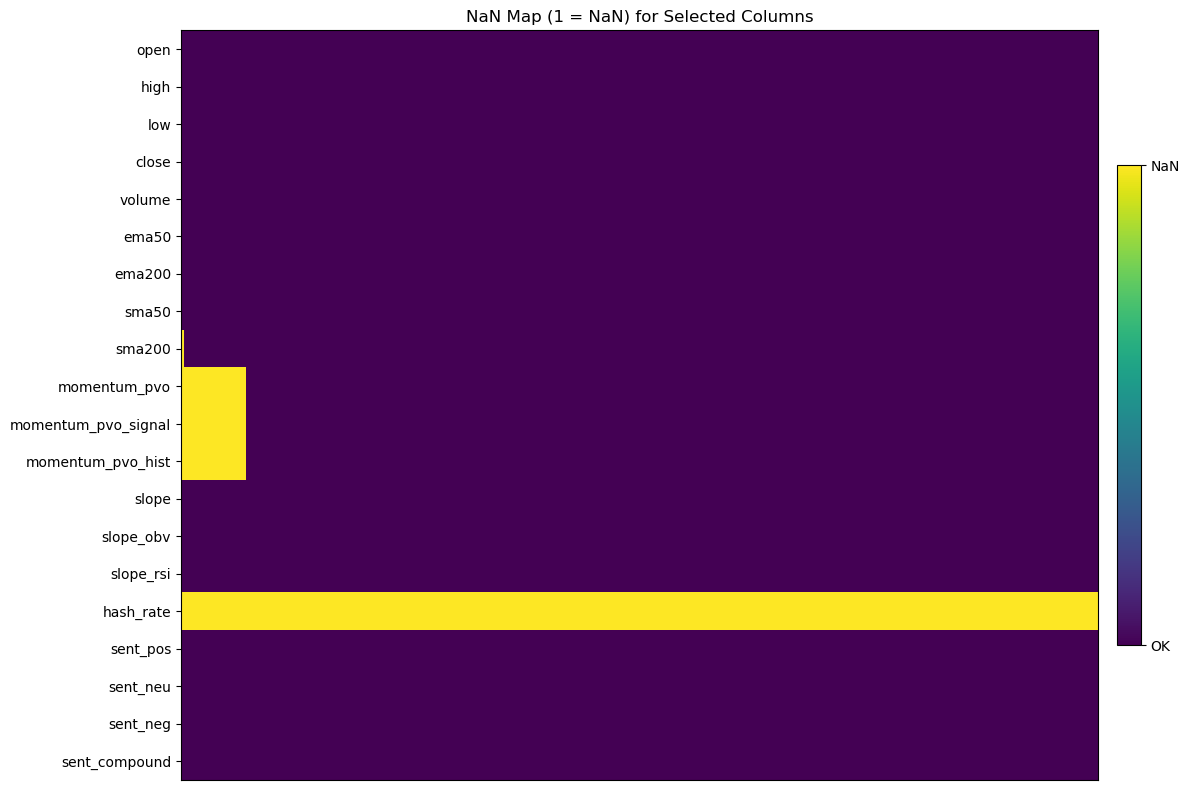

In [21]:
# ===== NaN Heatmap (includes network + sentiment; alias-aware) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Pick a dataframe to inspect
if "df_daily" in globals():
    df_to_check = df_daily
elif "dataset" in globals():
    df_to_check = dataset
elif "df" in globals():
    df_to_check = df
else:
    raise RuntimeError("No dataframe found. Expected one of: df_daily, dataset, or df.")

if not isinstance(df_to_check.index, pd.DatetimeIndex):
    raise TypeError("DataFrame index must be a DatetimeIndex.")

# --- Preferred feature names (+ aliases) to search for
preferred_cols = [
    # OHLCV
    "open","high","low","close","volume",
    # EMA/SMA
    "ema50","ema200","sma50","sma200",
    # RSI (various casings)
    "RSI","rsi","rsi14",
    # Bollinger
    "Bollinger_Upper","Bollinger_Lower","bb_up","bb_lo",
    # Popular momentum / slopes you have
    "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
    "slope","slope_obv","slope_rsi",
    "MACD","macd","OBV","obv",
    # NEW: network
    "hash_rate","mining_difficulty",
    # NEW: sentiment
    "sent_pos","sent_neu","sent_neg","sent_compound",
]

# Resolve aliases: pick the first name that exists in the dataframe for each logical feature set
alias_groups = [
    ["RSI","rsi","rsi14"],
    ["Bollinger_Upper","bb_up"],
    ["Bollinger_Lower","bb_lo"],
    ["MACD","macd"],
    ["OBV","obv"],
]
resolved = set()
for grp in alias_groups:
    for name in grp:
        if name in df_to_check.columns:
            resolved.add(name)
            break

# Start with any preferred columns actually present
cols_present = [c for c in preferred_cols if c in df_to_check.columns]
# Remove duplicate aliases within the same logical group
cols_present = list(dict.fromkeys(cols_present))  # keep order, drop dups
# Ensure only one of each alias group is kept
for grp in alias_groups:
    keep = [c for c in grp if c in cols_present]
    if len(keep) > 1:
        # keep the first occurrence in preferred order
        for c in keep[1:]:
            cols_present.remove(c)

if not cols_present:
    raise RuntimeError("No matching columns found for NaN heatmap. Check your dataframe columns.")

# If too many columns, focus on those with most NaNs (top_k)
top_k = 30
nan_counts = df_to_check[cols_present].isna().sum().sort_values(ascending=False)
if len(cols_present) > top_k:
    cols_to_plot = nan_counts.head(top_k).index.tolist()
    print(f"[INFO] Selected top {top_k} columns by NaNs for plotting.")
else:
    cols_to_plot = cols_present

# Optionally downsample rows for speed (visual only)
max_rows = 10000
if len(df_to_check) > max_rows:
    # take evenly spaced indices
    take_idx = np.linspace(0, len(df_to_check)-1, max_rows, dtype=int)
    df_plot = df_to_check.iloc[take_idx][cols_to_plot]
else:
    df_plot = df_to_check[cols_to_plot]

# Build mask: 1 = NaN, 0 = OK
mask = df_plot.isna().astype(int).values.T  # shape: cols x rows

plt.figure(figsize=(12, 3 + 0.25*len(cols_to_plot)))
im = plt.imshow(mask, aspect="auto", interpolation="nearest")
plt.yticks(range(len(cols_to_plot)), cols_to_plot)
plt.xticks([], [])
plt.title("NaN Map (1 = NaN) for Selected Columns")
cbar = plt.colorbar(im, fraction=0.025, pad=0.02)
cbar.set_ticks([0, 1]); cbar.set_ticklabels(["OK", "NaN"])
plt.tight_layout()
plt.show()


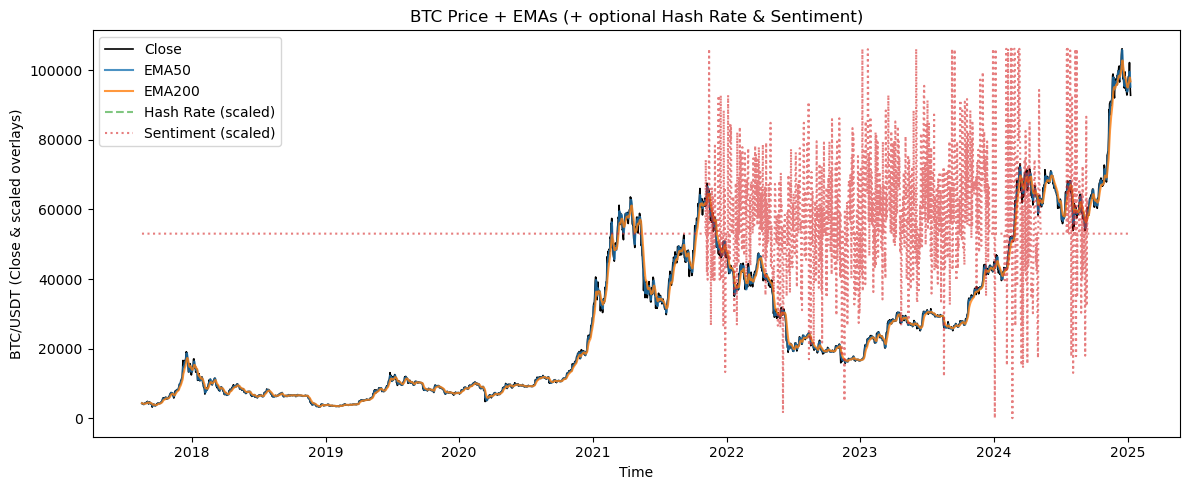

In [22]:
# ===== Sanity overlay plot: Price + EMAs + (optional) Network =====
import matplotlib.pyplot as plt

# Pick the right dataframe (daily preferred)
if "df_daily" in globals():
    df_plot = df_daily
elif "dataset" in globals():
    df_plot = dataset
elif "df" in globals():
    df_plot = df
else:
    raise RuntimeError("No dataframe found. Expected df_daily, dataset, or df.")

plt.figure(figsize=(12,5))

# --- Price
plt.plot(df_plot.index, df_plot["close"], label="Close", color="black", linewidth=1.2)

# --- EMAs (if available)
if "ema50" in df_plot.columns:  
    plt.plot(df_plot.index, df_plot["ema50"],  label="EMA50", alpha=0.8)
if "ema200" in df_plot.columns: 
    plt.plot(df_plot.index, df_plot["ema200"], label="EMA200", alpha=0.8)

# --- Optionally overlay hash rate (scaled for visualization)
if "hash_rate" in df_plot.columns:
    hr_scaled = (df_plot["hash_rate"] / df_plot["hash_rate"].max()) * df_plot["close"].max()
    plt.plot(df_plot.index, hr_scaled, label="Hash Rate (scaled)", linestyle="--", alpha=0.6)

# --- Optionally overlay sentiment compound (scaled)
if "sent_compound" in df_plot.columns:
    sent_scaled = (df_plot["sent_compound"] - df_plot["sent_compound"].min())
    sent_scaled = sent_scaled / (sent_scaled.max() + 1e-8) * df_plot["close"].max()
    plt.plot(df_plot.index, sent_scaled, label="Sentiment (scaled)", linestyle=":", alpha=0.6)

plt.title("BTC Price + EMAs (+ optional Hash Rate & Sentiment)")
plt.xlabel("Time")
plt.ylabel("BTC/USDT (Close & scaled overlays)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


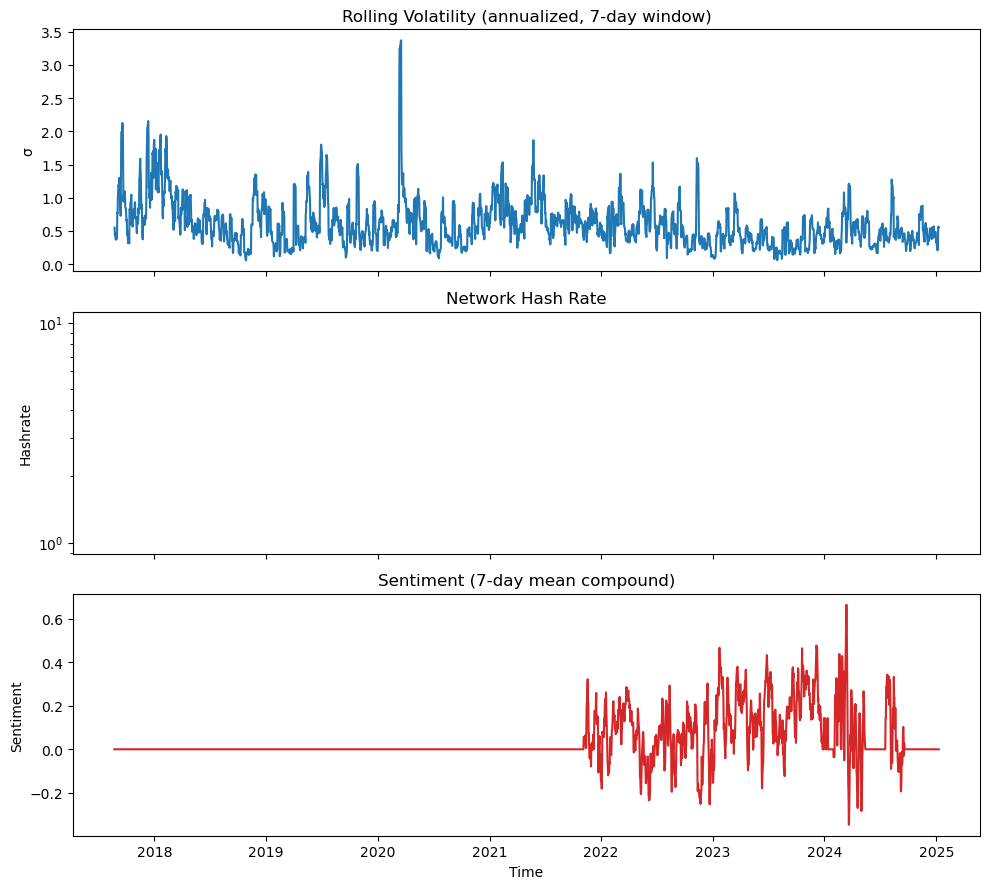

In [23]:
# ===== Rolling Volatility + Network + Sentiment =====
import matplotlib.pyplot as plt
import numpy as np

# Pick the correct df (daily preferred, fallback hourly)
if "df_daily" in globals():
    df_vol = df_daily
elif "df" in globals():
    df_vol = df
else:
    raise RuntimeError("No dataframe found. Expected df_daily or df.")

# --- Compute hourly/daily returns depending on data freq ---
if df_vol.index.freq is not None and "D" in str(df_vol.index.freq):
    # daily data
    ret = df_vol["close"].pct_change()
    roll_vol = ret.rolling(7).std() * np.sqrt(365)   # 7-day rolling, annualized
else:
    # hourly data
    ret = df_vol["close"].pct_change()
    roll_vol = ret.rolling(24*7).std() * np.sqrt(24*365)  # 7-day window, annualized

# --- Sentiment (smoothed 7-day mean if available) ---
sent = None
if "sent_compound" in df_vol.columns:
    sent = df_vol["sent_compound"].rolling(7).mean()

# --- Hash rate (log scale if available) ---
hashrate = None
if "hash_rate" in df_vol.columns:
    hashrate = df_vol["hash_rate"]

# --- Plot ---
nrows = 1 + int(hashrate is not None) + int(sent is not None)
fig, axes = plt.subplots(nrows=nrows, figsize=(10, 3*nrows), sharex=True)

if nrows == 1:
    axes = [axes]  # make iterable

# Panel 1: Volatility
axes[0].plot(roll_vol.index, roll_vol.values, color="tab:blue")
axes[0].set_title("Rolling Volatility (annualized, 7-day window)")
axes[0].set_ylabel("σ")

row = 1
if hashrate is not None:
    axes[row].plot(hashrate.index, hashrate.values, color="tab:green")
    axes[row].set_title("Network Hash Rate")
    axes[row].set_ylabel("Hashrate")
    axes[row].set_yscale("log")
    row += 1

if sent is not None:
    axes[row].plot(sent.index, sent.values, color="tab:red")
    axes[row].set_title("Sentiment (7-day mean compound)")
    axes[row].set_ylabel("Sentiment")
    row += 1

plt.xlabel("Time")
plt.tight_layout()
plt.show()


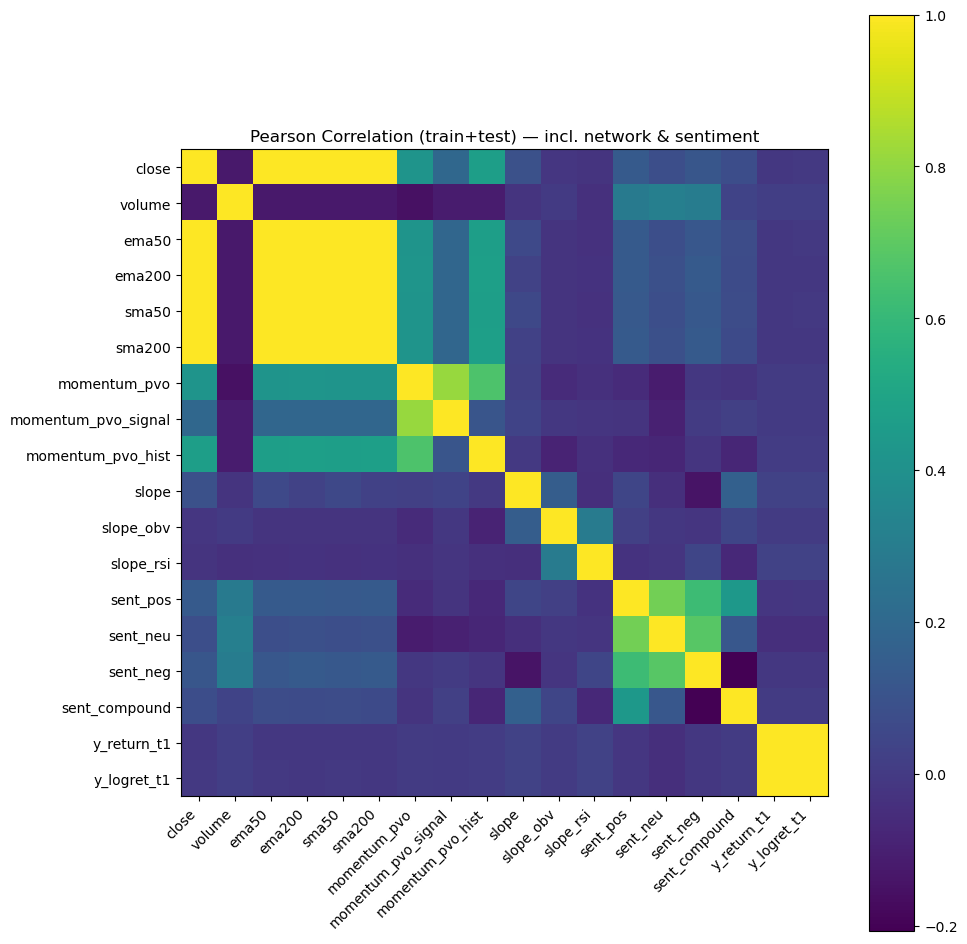

In [24]:
# ===== Correlation heatmap (includes network + sentiment; alias-aware; numeric-only) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Choose a dataframe (use your modeling matrix by default)
df_corr = dataset.copy()

# --- Candidate features (with aliases)
cands_pref = [
    # Core market
    "close","volume",
    # EMAs / SMAs
    "ema50","ema200","sma50","sma200",
    # RSI variants
    "RSI","rsi","rsi14",
    # Bollinger
    "Bollinger_Upper","Bollinger_Lower","bb_up","bb_lo",
    # Momentum / slopes (if present in your data)
    "MACD","macd","OBV","obv",
    "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
    "slope","slope_obv","slope_rsi",
    # NEW: network
    "hash_rate","mining_difficulty",
    # NEW: sentiment
    "sent_pos","sent_neu","sent_neg","sent_compound",
    # Target (optional)
    "y_return_t1","y_logret_t1"
]

# Alias groups → keep the first one that exists
alias_groups = [
    ["RSI","rsi","rsi14"],
    ["Bollinger_Upper","bb_up"],
    ["Bollinger_Lower","bb_lo"],
    ["MACD","macd"],
    ["OBV","obv"],
]

# Keep only present columns in preferred order
present = [c for c in cands_pref if c in df_corr.columns]

# De-dup aliases within same logical group
for grp in alias_groups:
    found = [c for c in grp if c in present]
    if len(found) > 1:
        # Keep only the first one in the group (based on cands_pref ordering)
        for c in found[1:]:
            present.remove(c)

# If nothing matched, fall back to any numeric columns
if not present:
    present = df_corr.select_dtypes(include=[np.number]).columns.tolist()

# Restrict to numeric and drop all-NaN columns
numeric = df_corr[present].select_dtypes(include=[np.number])
numeric = numeric.dropna(axis=1, how="all")

# If still too wide, pick top-k by variance (more informative)
top_k = 20
if numeric.shape[1] > top_k:
    variances = numeric.var().sort_values(ascending=False)
    keep_cols = variances.head(top_k).index.tolist()
    numeric = numeric[keep_cols]
else:
    keep_cols = numeric.columns.tolist()

# Compute Pearson correlation with pairwise complete observations
corr = numeric.corr(method="pearson")

plt.figure(figsize=(max(6, 0.45*len(keep_cols)+2), max(5, 0.45*len(keep_cols)+2)))
plt.imshow(corr.values, interpolation="nearest")
plt.xticks(range(len(keep_cols)), keep_cols, rotation=45, ha="right")
plt.yticks(range(len(keep_cols)), keep_cols)
plt.title("Pearson Correlation (train+test) — incl. network & sentiment")
plt.colorbar()
plt.tight_layout()
plt.show()


In [25]:
# ===== Prove inputs are shifted correctly =====
# Pick a feature to test — priority order: technical → network → sentiment → fallback
preferred_order = [
    "ema50","ema200","sma50","sma200",
    "hash_rate","mining_difficulty",
    "sent_compound","sent_pos","sent_neg","sent_neu"
]
feature = next((f for f in preferred_order if f in dataset.columns), dataset.columns[0])

# Ensure target exists
assert "y_return_t1" in dataset.columns or "y_close_t1" in dataset.columns, "Target not found."

target_col = "y_return_t1" if "y_return_t1" in dataset.columns else "y_close_t1"

# Slice down to feature + target, drop NaNs
ds = dataset[[feature, target_col]].dropna()

# Correlation between feature(t) and target(t+1)
corr_pair = ds[feature].corr(ds[target_col])
print(f"[SHIFT CHECK] Feature: {feature} | Target: {target_col}")
print(f"Correlation {feature}(t) vs {target_col}(t+1): {corr_pair:.4f}")

# Show sample rows to illustrate shift
print("\nFirst few rows showing alignment (feature at t vs target at t+1):")
print(ds.head(5))


[SHIFT CHECK] Feature: ema50 | Target: y_return_t1
Correlation ema50(t) vs y_return_t1(t+1): -0.0114

First few rows showing alignment (feature at t vs target at t+1):
                   ema50  y_return_t1
open_time                            
2018-02-26   9711.080761     0.023735
2018-02-27   9880.653287    -0.022924
2018-02-28  10319.186092     0.057447
2018-03-01  10472.402790     0.010897
2018-03-02  10630.940413     0.038543


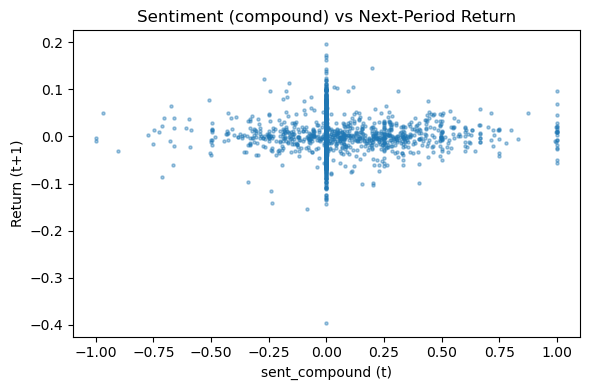

In [26]:
# ===== Scatter: Technical (RSI) / Network (hash_rate) / Sentiment (sent_compound) vs Next-Period Return =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "dataset" in globals(), "Run the pipeline to create `dataset` first."
assert "y_return_t1" in dataset.columns, "`y_return_t1` missing."

# Choose RSI alias if present
rsi_col = next((c for c in ["rsi14","RSI","rsi"] if c in dataset.columns), None)

# Common helper to sample for lighter plotting
def _sample(df, n=5000, seed=42):
    if len(df) <= n:
        return df
    return df.sample(n, random_state=seed)

# 1) RSI vs next-period return
if rsi_col is not None:
    ds = dataset[[rsi_col, "y_return_t1"]].dropna()
    if len(ds) >= 10:
        sample = _sample(ds, 5000)
        plt.figure(figsize=(6,4))
        plt.scatter(sample[rsi_col].values, sample["y_return_t1"].values, s=5, alpha=0.4)
        freq_label = "Next-Day" if (dataset.index.to_series().diff().median() >= pd.Timedelta(hours=23)) else "Next-Hour"
        plt.title(f"{rsi_col.upper()} vs {freq_label} Return")
        plt.xlabel(f"{rsi_col} (t)")
        plt.ylabel("Return (t+1)")
        plt.tight_layout()
        plt.show()

# 2) Hash rate vs next-period return (if available); use log scale on X if wide range
if "hash_rate" in dataset.columns:
    ds = dataset[["hash_rate", "y_return_t1"]].dropna()
    if len(ds) >= 10:
        sample = _sample(ds, 5000)
        x = sample["hash_rate"].astype(float).values
        # decide whether to log-scale
        do_log = (np.nanmax(x) / max(np.nanmin(x[x>0]) if np.any(x>0) else 1.0, 1.0)) > 100.0
        x_plot = np.log(x) if (do_log and np.all(x > 0)) else x
        plt.figure(figsize=(6,4))
        plt.scatter(x_plot, sample["y_return_t1"].values, s=5, alpha=0.4)
        plt.title("Hash Rate vs Next-Period Return")
        plt.xlabel("log(hash_rate) (t)" if (do_log and np.all(x > 0)) else "hash_rate (t)")
        plt.ylabel("Return (t+1)")
        plt.tight_layout()
        plt.show()

# 3) Sentiment compound vs next-period return (if available)
if "sent_compound" in dataset.columns:
    ds = dataset[["sent_compound", "y_return_t1"]].dropna()
    if len(ds) >= 10:
        sample = _sample(ds, 5000)
        plt.figure(figsize=(6,4))
        plt.scatter(sample["sent_compound"].values, sample["y_return_t1"].values, s=5, alpha=0.4)
        plt.title("Sentiment (compound) vs Next-Period Return")
        plt.xlabel("sent_compound (t)")
        plt.ylabel("Return (t+1)")
        plt.tight_layout()
        plt.show()


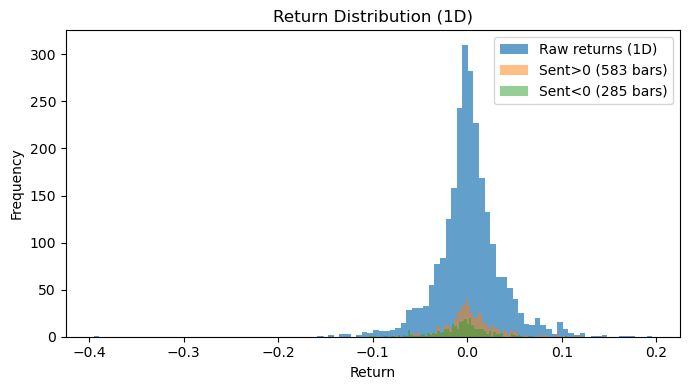

In [27]:
# ==== Return Distribution Plot (with new features awareness) ====
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

assert "dataset" in globals(), "Run the pipeline first."

# Determine cadence: hourly vs daily
median_diff = dataset.index.to_series().diff().median()
is_daily = median_diff >= pd.Timedelta(hours=23)
freq_label = "1D" if is_daily else "1H"

# Compute returns
ret = dataset["close"].pct_change().dropna()

plt.figure(figsize=(7,4))
plt.hist(ret.values, bins=100, alpha=0.7, label=f"Raw returns ({freq_label})")

# --- Optional overlays ---
# Sentiment overlay (if compound available): split distribution by pos vs neg
if "sent_compound" in dataset.columns:
    sent = dataset["sent_compound"].reindex(ret.index).fillna(0.0)
    mask_pos = sent > 0
    mask_neg = sent < 0
    if mask_pos.any():
        plt.hist(ret[mask_pos].values, bins=100, alpha=0.5, label=f"Sent>0 ({mask_pos.sum()} bars)")
    if mask_neg.any():
        plt.hist(ret[mask_neg].values, bins=100, alpha=0.5, label=f"Sent<0 ({mask_neg.sum()} bars)")

# Hash rate regime overlay (if available)
if "hash_rate" in dataset.columns:
    hr = dataset["hash_rate"].reindex(ret.index).dropna()
    if len(hr) > 20:
        median_hr = hr.median()
        mask_high = hr >= median_hr
        mask_low  = hr < median_hr
        plt.hist(ret[mask_high].values, bins=100, alpha=0.3, label="High hash_rate")
        plt.hist(ret[mask_low].values,  bins=100, alpha=0.3, label="Low hash_rate")

plt.title(f"Return Distribution ({freq_label})")
plt.xlabel("Return"); plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


[REG] Target=y_logret_t1 | Test RMSE=0.027981 | MAE=0.020505 | R2=-0.1506


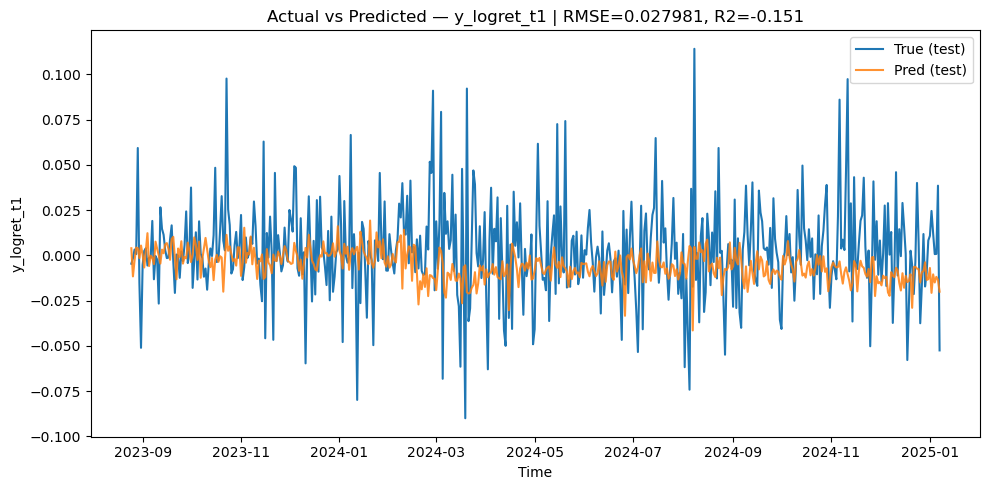

In [29]:
# ===== STEP R: Run a regression to produce `reg_preds` + targets =====
# - Creates y_logret_t1, y_return_t1, y_close_t1
# - Uses your `final_features` if present; otherwise builds a minimal feature set
# - Trains RandomForestRegressor (time-based split), generates `reg_preds` (Series)
# - Plots Actual vs Predicted on test (single matplotlib plot)
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

assert "dataset" in globals(), "`dataset` DataFrame is required."

# ---------- 0) Ensure we have a price column ----------
def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

close_col = _find_col(dataset, ["close","Close","close_price","price","btc_close","close_usd"])
if close_col is None:
    # Optional: load from CSV if needed (adjust path to your environment)
    csv_path = "/mnt/data/btc1h_usdt.csv"
    if not os.path.exists(csv_path):
        raise RuntimeError("No 'close' column found in `dataset` and fallback CSV missing.")
    raw = pd.read_csv(csv_path)
    ts_col = _find_col(raw, ["timestamp","open_time","date","time","datetime"]) or raw.columns[0]
    ts = raw[ts_col]
    idx = pd.to_datetime(ts, unit="ms" if np.issubdtype(ts.dtype, np.number) and ts.max()>1e11 else "s", errors="coerce")
    ccol = _find_col(raw, ["close","Close","close_price","price"]) or raw.columns[1]
    df_add = pd.DataFrame({"close": pd.to_numeric(raw[ccol], errors="coerce")}, index=idx).sort_index()
    dataset = dataset.copy()
    dataset = dataset.join(df_add, how="left")
    close_col = "close"

# ---------- 1) Targets ----------
ds = dataset.sort_index().copy()
# Next close
ds["y_close_t1"]  = ds[close_col].shift(-1)
# Simple return to next bar
ds["y_return_t1"] = ds[close_col].pct_change().shift(-1)
# Log-return to next bar (safer numerically)
ds["y_logret_t1"] = np.log(ds[close_col].shift(-1) / ds[close_col]).replace([np.inf, -np.inf], np.nan)

# Choose which target to predict (your residual code prefers this order)
TARGET_NAME = "y_logret_t1"   # change to "y_return_t1" or "y_close_t1" if you like

assert TARGET_NAME in ds.columns, f"{TARGET_NAME} not found after target creation."

# ---------- 2) Feature set ----------
def ema(s: pd.Series, span: int) -> pd.Series:
    return s.ewm(span=span, adjust=False).mean()

def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    d = series.diff()
    up = np.where(d > 0, d, 0.0)
    dn = np.where(d < 0, -d, 0.0)
    roll_up = pd.Series(up, index=series.index).rolling(period).mean()
    roll_dn = pd.Series(dn, index=series.index).rolling(period).mean()
    rs = roll_up / (roll_dn + 1e-12)
    return 100.0 - 100.0 / (1.0 + rs)

if "final_features" in globals() and isinstance(final_features, (list, tuple)) and final_features:
    base_feats = list(final_features)
else:
    # Minimal default features (safe if you don’t have `final_features`)
    ds["ret_1"]  = ds[close_col].pct_change()
    ds["ema_12"] = ema(ds[close_col], 12)
    ds["ema_26"] = ema(ds[close_col], 26)
    ds["rsi_14"] = rsi(ds[close_col], 14)
    ds["vol_24"] = ds[close_col].rolling(24).std()
    base_feats = ["ret_1","ema_12","ema_26","rsi_14","vol_24"]

# Lag features to avoid lookahead bias
feat_cols = []
for c in base_feats:
    if c in ds.columns:
        lc = f"{c}_lag1"
        ds[lc] = ds[c].shift(1)
        feat_cols.append(lc)

# Optional: include exogenous if present
for extra in ["hash_rate","sent_compound"]:
    if extra in ds.columns:
        lc = f"{extra}_lag1"
        ds[lc] = ds[extra].shift(1)
        feat_cols.append(lc)

# ---------- 3) Modeling frame ----------
model_df = ds[feat_cols + [TARGET_NAME, close_col]].dropna().copy()
if len(model_df) < 300:
    raise RuntimeError(f"Not enough rows after feature engineering (got {len(model_df)}).")

X = model_df[feat_cols].values
y = model_df[TARGET_NAME].values
idx_all = model_df.index

# ---------- 4) Time-based split (80/20) ----------
n = len(model_df)
n_train = int(n * 0.8)
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]
idx_train, idx_test = idx_all[:n_train], idx_all[n_train:]

# ---------- 5) Train regressor ----------
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# ---------- 6) Metrics ----------
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"[REG] Target={TARGET_NAME} | Test RMSE={rmse:.6f} | MAE={mae:.6f} | R2={r2:.4f}")

# ---------- 7) Expose `reg_preds` as a Series aligned to `dataset` ----------
reg_preds = pd.Series(index=dataset.index, dtype=float, name="reg_preds")
reg_preds.loc[idx_test] = y_pred  # predictions only for test slice

# (Optional) Also expose for convenience:
y_test_series = pd.Series(y_test, index=idx_test, name="y_true")
y_pred_series = pd.Series(y_pred, index=idx_test, name="y_pred")

# ---------- 8) Quick sanity plot (single figure) ----------
plt.figure(figsize=(10,5))
plt.plot(y_test_series.index, y_test_series.values, label="True (test)")
plt.plot(y_pred_series.index, y_pred_series.values, label="Pred (test)", alpha=0.85)
plt.title(f"Actual vs Predicted — {TARGET_NAME} | RMSE={rmse:.6f}, R2={r2:.3f}")
plt.xlabel("Time")
plt.ylabel(TARGET_NAME)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [30]:
### ===== Longest NaN streaks (cadence-aware; highlights network & sentiment) =====
import pandas as pd
import numpy as np

def longest_nan_streak(s: pd.Series) -> int:
    """Longest consecutive NaN run length."""
    m = s.isna().astype(int).values
    best = run = 0
    for v in m:
        run = run + 1 if v == 1 else 0
        if run > best:
            best = run
    return int(best)

# --- Pick a dataframe: prefer daily (cleaner), else modeling dataset, else raw df
if "df_daily" in globals():
    df_check = df_daily.copy()
elif "dataset" in globals():
    df_check = dataset.copy()
elif "df" in globals():
    df_check = df.copy()
else:
    raise RuntimeError("No dataframe found. Expected df_daily, dataset, or df.")

if not isinstance(df_check.index, pd.DatetimeIndex):
    raise TypeError("DataFrame index must be a DatetimeIndex.")

# --- Cadence detection (used only for labeling)
med_step = df_check.index.to_series().diff().median()
is_daily = (med_step is not pd.NaT) and (med_step >= pd.Timedelta(hours=23))
freq_label = "days" if is_daily else "bars"

# --- Numeric columns only
num_cols = df_check.select_dtypes(include=[np.number]).columns.tolist()
if not num_cols:
    raise RuntimeError("No numeric columns to analyze.")

# --- Compute longest streaks for all numeric columns
streaks = {c: longest_nan_streak(df_check[c]) for c in num_cols}
streaks = pd.Series(streaks).sort_values(ascending=False)

print(f"Top NaN streaks (units = consecutive {freq_label}):")
print(streaks.head(10))

# --- Highlight the NEW feature group explicitly
watch_cols = ["hash_rate", "mining_difficulty", "sent_pos", "sent_neu", "sent_neg", "sent_compound"]
present_watch = [c for c in watch_cols if c in df_check.columns]
if present_watch:
    print("\n[Network & Sentiment] Longest NaN streaks:")
    for c in present_watch:
        print(f"  {c:>16}: {longest_nan_streak(df_check[c])} {freq_label}")

# --- Optional: bucket summary (market / technical / network / sentiment)
feature_catalog = globals().get("feature_catalog", {
    "market": ["open","high","low","close","volume"],
    "technical": [
        "sma200","sma50","ema200","ema50","RSI","rsi","slope_rsi","MACD","macd",
        "OBV","obv","Bollinger_Upper","Bollinger_Lower",
        "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
        "slope","slope_obv"
    ],
    "network": ["hash_rate","mining_difficulty"],
    "sentiment": ["sent_pos","sent_neu","sent_neg","sent_compound"],
})

# Map each present column to a bucket; others → 'other'
bucket_of = {}
for b, cols in feature_catalog.items():
    for c in cols:
        bucket_of[c] = b

streak_df = streaks.to_frame("longest_streak")
streak_df["bucket"] = [bucket_of.get(c, "other") for c in streak_df.index]

# Longest streak per bucket (max)
bucket_max = streak_df.groupby("bucket")["longest_streak"].max().sort_values(ascending=False)
print("\nMax NaN streak by bucket:")
print(bucket_max)

# (Optional) show worst offender per bucket
print("\nWorst column per bucket:")
worst_rows = []
for b in bucket_max.index:
    sub = streak_df[streak_df["bucket"] == b]
    if not sub.empty:
        worst = sub.sort_values("longest_streak", ascending=False).iloc[0]
        worst_rows.append((b, worst.name, int(worst["longest_streak"])))
for b, col, v in worst_rows:
    print(f"  {b:>10}: {col} → {v} {freq_label}")


Top NaN streaks (units = consecutive days):
hash_rate              2703
momentum_pvo_hist       192
momentum_pvo            192
momentum_pvo_signal     192
sma200                    8
trend_stc                 3
sma50                     2
trend_trix                1
trend_macd_diff           1
trend_macd                1
dtype: int64

[Network & Sentiment] Longest NaN streaks:
         hash_rate: 2703 days
          sent_pos: 0 days
          sent_neu: 0 days
          sent_neg: 0 days
     sent_compound: 0 days

Max NaN streak by bucket:
bucket
network      2703
technical     192
other           3
market          0
sentiment       0
Name: longest_streak, dtype: int64

Worst column per bucket:
     network: hash_rate → 2703 days
   technical: momentum_pvo_hist → 192 days
       other: trend_stc → 3 days
      market: open → 0 days
   sentiment: sent_neg → 0 days


[INFO] HMM not computed (install hmmlearn or more data needed): No module named 'hmmlearn'
Regime counts (MA):
regime_MA
Bull        1494
Bear         982
Sideways      33
Name: count, dtype: int64

Regime counts (RET):
regime_RET
Sideways    1074
Bull         868
Bear         567
Name: count, dtype: int64

Regime counts (RV):
regime_RV
Bull-Quiet       694
Bull-Volatile    671
Bear-Volatile    559
Bear-Quiet       555
Unknown           30
Name: count, dtype: int64

Regime counts (HMM):
regime_HMM
NaN    2509
Name: count, dtype: int64


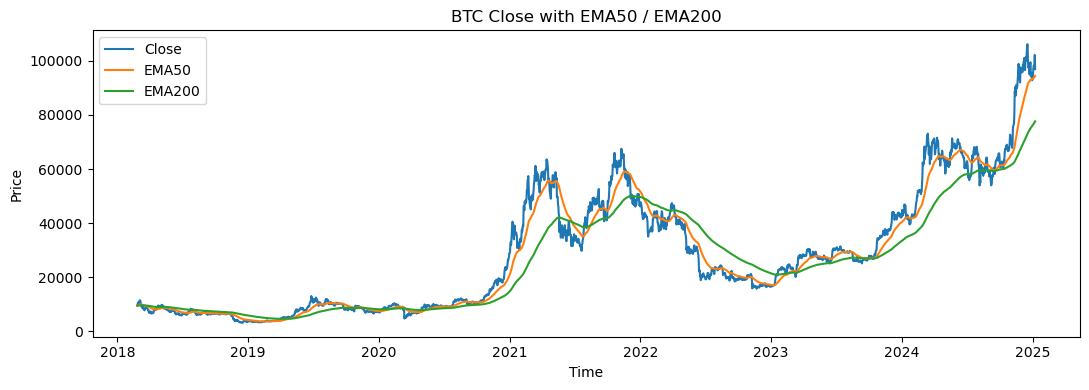

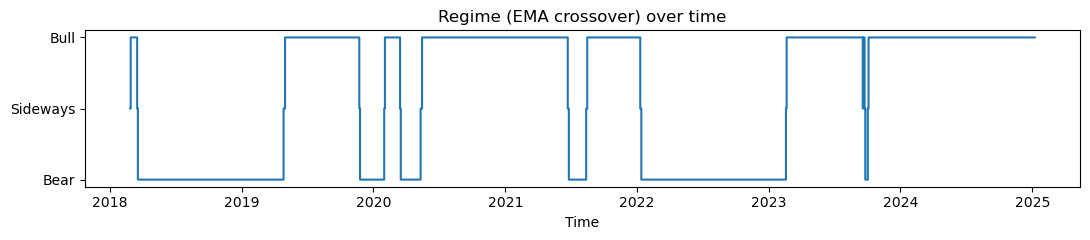

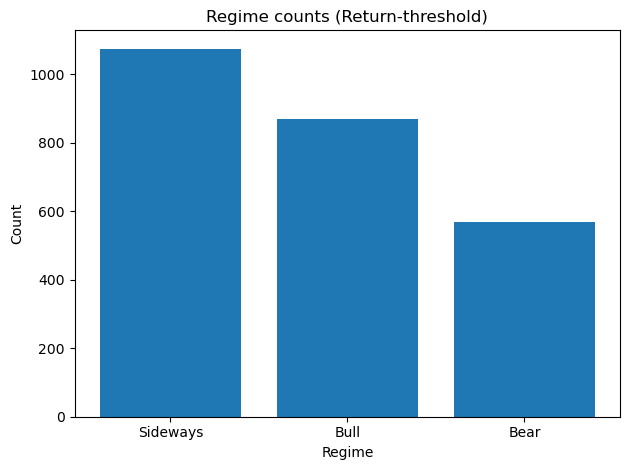

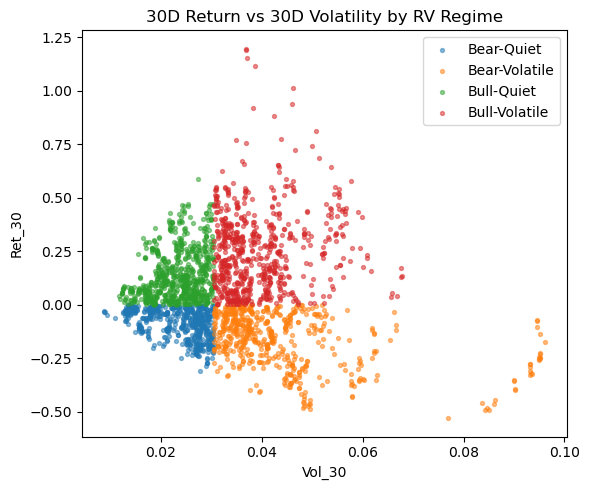

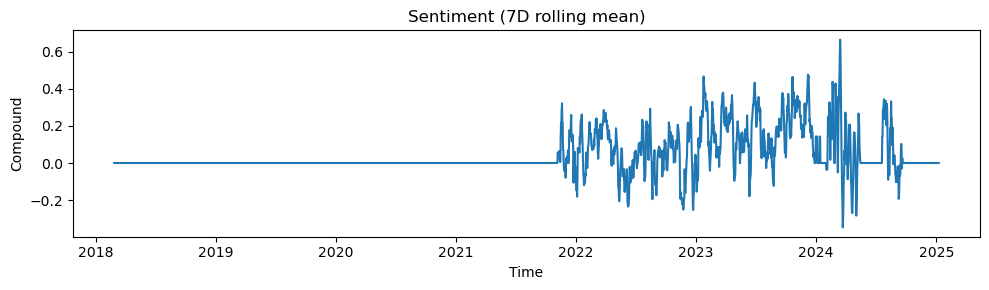

Added 11 regime dummies to final_features.


In [32]:
# ===== Market Regime Features + Simple Graphs (refactored for our features) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Pick / build the working DataFrame (DAILY preferred)
def _find_col(df, cands):
    for c in cands:
        if c in df.columns:
            return c
    return None

if "dataset" in globals():
    df_src = dataset.copy()
elif "df_daily" in globals():
    df_src = df_daily.copy()
else:
    raise RuntimeError("No dataframe found. Expected `dataset` or `df_daily`.")

if not isinstance(df_src.index, pd.DatetimeIndex):
    raise TypeError("Index must be a DatetimeIndex.")

df_src = df_src.sort_index()

# If sub-daily, aggregate to DAILY for regime inference
close_col = _find_col(df_src, ["close","Close","price","close_usd","btc_close"])
if close_col is None:
    raise RuntimeError("No close/price column found in the data.")

cols_to_keep = {close_col: "close"}
if "hash_rate" in df_src.columns:
    cols_to_keep["hash_rate"] = "hash_rate"
if "sent_compound" in df_src.columns:
    cols_to_keep["sent_compound"] = "sent_compound"

df_use = df_src[list(cols_to_keep.keys())].rename(columns=cols_to_keep)

if (len(df_use) >= 2) and ((df_use.index[1] - df_use.index[0]).total_seconds() <= 3600 + 1):
    # Hourly (or faster) → daily
    agg = {"close": "last"}
    if "hash_rate" in df_use.columns:       agg["hash_rate"] = "mean"
    if "sent_compound" in df_use.columns:   agg["sent_compound"] = "mean"
    df_reg = df_use.resample("1D").apply(agg).dropna(subset=["close"])
else:
    df_reg = df_use.copy()

# 1) Technical helpers (compute if missing)
if "ema50" not in df_reg.columns:
    df_reg["ema50"] = df_reg["close"].ewm(span=50, adjust=False).mean()
if "ema200" not in df_reg.columns:
    df_reg["ema200"] = df_reg["close"].ewm(span=200, adjust=False).mean()

df_reg["ret_1"]  = df_reg["close"].pct_change()
df_reg["ret_30"] = df_reg["close"].pct_change(30)
df_reg["vol_30"] = df_reg["ret_1"].rolling(30, min_periods=10).std()

# 2) Regime 1: EMA crossover with adaptive buffer
spread = (df_reg["ema50"] - df_reg["ema200"]) / df_reg["ema200"]
buf = spread.rolling(10, min_periods=1).std().fillna(0) * 0.5
cond_bull = spread >  buf
cond_bear = spread < -buf
df_reg["regime_MA"] = np.where(cond_bull, "Bull", np.where(cond_bear, "Bear", "Sideways"))

# 3) Regime 2: Return-threshold (30D)
thr_up, thr_dn = 0.10, -0.10   # tweak if desired
df_reg["regime_RET"] = np.where(df_reg["ret_30"] > thr_up, "Bull",
                         np.where(df_reg["ret_30"] < thr_dn, "Bear", "Sideways"))

# 4) Regime 3: Return × Volatility (4 states)
vol_med = df_reg["vol_30"].median()
df_reg["regime_RV"] = np.select(
    [
        (df_reg["ret_30"] > 0) & (df_reg["vol_30"] < vol_med),
        (df_reg["ret_30"] > 0) & (df_reg["vol_30"] >= vol_med),
        (df_reg["ret_30"] <= 0) & (df_reg["vol_30"] < vol_med),
        (df_reg["ret_30"] <= 0) & (df_reg["vol_30"] >= vol_med),
    ],
    ["Bull-Quiet", "Bull-Volatile", "Bear-Quiet", "Bear-Volatile"],
    default="Unknown"
)

# 5) (Optional) Regime 4: HMM on returns
df_reg["regime_HMM"] = np.nan
try:
    from hmmlearn.hmm import GaussianHMM
    rets = df_reg["ret_1"].dropna().values.reshape(-1, 1)
    if len(rets) > 500:
        hmm = GaussianHMM(n_components=3, covariance_type="full", random_state=42)
        hmm.fit(rets)
        st = pd.Series(hmm.predict(rets), index=df_reg["ret_1"].dropna().index, name="state")
        # map by state mean
        stats = []
        for s in np.unique(st.values):
            s_vals = df_reg.loc[st.index[st.values == s], "ret_1"]
            stats.append((s, float(s_vals.mean())))
        order = [s for s, _ in sorted(stats, key=lambda x: x[1])]
        hmm_map = {order[0]: "Bear", order[1]: "Sideways", order[2]: "Bull"} if len(order) == 3 else {
            order[0]: "Bear", order[-1]: "Bull"
        }
        df_reg.loc[st.index, "regime_HMM"] = st.map(hmm_map).values
except Exception as e:
    print("[INFO] HMM not computed (install hmmlearn or more data needed):", e)

# 6) One-hot encodings (and append to final_features if we use them downstream)
dummy_cols_added = []
for col in ["regime_MA", "regime_RET", "regime_RV", "regime_HMM"]:
    if col in df_reg.columns:
        d = pd.get_dummies(df_reg[col], prefix=col, dummy_na=False)
        keep = [c for c in d.columns if d[c].sum() > 0]
        d = d[keep]
        df_reg = df_reg.join(d)
        dummy_cols_added.extend(list(d.columns))

# 7) QUICK STATS
print("Regime counts (MA):")
print(df_reg["regime_MA"].value_counts(dropna=False))
print("\nRegime counts (RET):")
print(df_reg["regime_RET"].value_counts(dropna=False))
print("\nRegime counts (RV):")
print(df_reg["regime_RV"].value_counts(dropna=False))
if "regime_HMM" in df_reg.columns:
    print("\nRegime counts (HMM):")
    print(df_reg["regime_HMM"].value_counts(dropna=False))

# 8) PLOTS (single-plot figs)
# 8.1 Price + EMAs
plt.figure(figsize=(11,4))
plt.plot(df_reg.index, df_reg["close"], label="Close")
plt.plot(df_reg.index, df_reg["ema50"], label="EMA50")
plt.plot(df_reg.index, df_reg["ema200"], label="EMA200")
plt.title("BTC Close with EMA50 / EMA200")
plt.xlabel("Time"); plt.ylabel("Price"); plt.legend(); plt.tight_layout(); plt.show()

# 8.2 Regime timeline (MA) as ints
map_ma = {"Bear": -1, "Sideways": 0, "Bull": 1}
ma_series = df_reg["regime_MA"].map(map_ma)
plt.figure(figsize=(11,2.5))
plt.plot(ma_series.index, ma_series.values, drawstyle="steps-post")
plt.yticks(sorted(map_ma.values()), ["Bear","Sideways","Bull"])
plt.title("Regime (EMA crossover) over time")
plt.xlabel("Time"); plt.tight_layout(); plt.show()

# 8.3 Regime distribution bars (RET)
ret_counts = df_reg["regime_RET"].value_counts()
plt.figure()
plt.bar(ret_counts.index.astype(str), ret_counts.values)
plt.title("Regime counts (Return-threshold)")
plt.xlabel("Regime"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

# 8.4 Return vs Volatility scatter (colored by RV labels)
rv_sample = df_reg.dropna(subset=["ret_30","vol_30","regime_RV"])
if len(rv_sample) > 4000:
    rv_sample = rv_sample.sample(4000, random_state=42)
groups = rv_sample.groupby("regime_RV")
plt.figure(figsize=(6,5))
for name, g in groups:
    plt.scatter(g["vol_30"].values, g["ret_30"].values, s=8, alpha=0.5, label=name)
plt.title("30D Return vs 30D Volatility by RV Regime")
plt.xlabel("Vol_30"); plt.ylabel("Ret_30"); plt.legend(); plt.tight_layout(); plt.show()

# 8.5 (Optional) Overlay network/sentiment
if "hash_rate" in df_reg.columns:
    plt.figure(figsize=(10,3))
    plt.plot(df_reg.index, df_reg["hash_rate"])
    plt.title("Hash Rate (daily mean)"); plt.xlabel("Time"); plt.ylabel("Hash Rate")
    plt.tight_layout(); plt.show()

if "sent_compound" in df_reg.columns:
    plt.figure(figsize=(10,3))
    plt.plot(df_reg.index, df_reg["sent_compound"].rolling(7, min_periods=1).mean())
    plt.title("Sentiment (7D rolling mean)"); plt.xlabel("Time"); plt.ylabel("Compound")
    plt.tight_layout(); plt.show()

# 9) Hand back for downstream use and update final_features (optional)
df_daily = df_reg  # persist daily regimes
# If you want to include regime one-hots in modeling:
if "final_features" in globals() and isinstance(final_features, (list, tuple)):
    new_feats = [c for c in dummy_cols_added if c not in final_features]
    if new_feats:
        final_features = list(final_features) + new_feats
        print(f"Added {len(new_feats)} regime dummies to final_features.")
